# ESc1: features, validation and submission forecasts

This notebook develops a fixed **Ridge model on `dszl(10)` features**, evaluates it with rolling **two-calendar-year training / two-calendar-year forecast windows**, and exports its predictions for the final two-year price/label blackout. Raw predictions, dimensionless positions and diagnostic P&L are kept separate.

The first 80% of the labeled elapsed-time span is the **research sample**. Its remaining 20% is not scored or used to choose parameters here. Earlier project versions inspected a larger sample, so this is not a retrospectively pristine holdout. Only at the final, explicitly separated submission fit are the preceding two years of available labels used, including the research-reserved interval. The true blackout's labels are never used.

Every feature-family experiment uses all research rows; pair expansions are batched by columns, not subsampled. The notebook progresses from data/coverage checks, through transformation and predictor-forecast experiments, to model comparisons and the exact final configuration's validation backtest. Red TODOs identify open methodological issues rather than claiming they are solved.

`forecasts/ridge_walk_forward.*` contains research validation forecasts; `forecasts/ridge_oos.*` is the submission output. These are **raw `ret_5m` predictions**, not positions or P&L. The separate `asset_vol.ipynb` is a signal-only sizing audit, retained under the requested filename; it is not needed to generate the submission.


In [1]:
from pathlib import Path
import json, os, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.plotting import scatter_matrix
from scipy.cluster.hierarchy import dendrogram

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'takehome').exists())
sys.path.insert(0, str(ROOT / 'src'))
from takehome.data import column_coverage, training_data
from takehome.plots import heatmap
from takehome.eda import (
    acf_matrix, autocorrelation_table, bell_shape_table, correlation_clustering,
    correlation_to_column, infer_feature_cols, monthly_shift_scores, redundant_pairs,
)

DATA_PATH = Path(os.environ.get('DATA_PATH', ROOT / 'ESc1_signal_components_5min (6).parquet'))
SCATTER_N_FEATURES = 9  # Limit displayed columns, never observations.
ACF_LAG, SEASONAL_NLAGS = 15, 288
from takehome.features import ts_std, ewm_observed

get_ipython().run_line_magic('matplotlib', 'inline')
from IPython.display import display, Markdown
from takehome.data import read_parquet_window
from takehome.features import dszl_design
from takehome.normalization import signal_weights

# Fixed before scoring; no held-out data choose these settings.
HL, META_HL, DSZL_HL, WINDOW_YEARS, BATCH_SIZE = 6048, 252*288, 10, 2, 8
SIGNAL_RULE = dict(method='std', floor_fraction=.25, cap=3., lag=1)
RIDGE_CONFIG = dict(alpha=.01, decay=2**(-1/HL), fit_intercept=True)


## Shared EWM and exposure convention

EWM scales treat **zeros and nonfinite observations as missing**, use `ignore_na=True`, and require the stated number of observations. Exactly zero standard deviations remain undefined. `dszl(10)` uses this convention independently within each local clock-time group, including the currently observed feature; it does not use a return or future feature.

All main backtest plots now use the **same signal-only rule** carried over from the normalization comparison:

$$w_t=\operatorname{clip}\left(\frac{s_t}{\max(\widehat\sigma_{s,t-1},0.25\,\sigma_0)},-3,3\right),\qquad p_t=w_tR_t.$$

Here $\sigma_0$ is the **first valid lagged** signal scale and is then frozen. No full-period scale is fitted. The half-life/minimum observations are 6,048; missing signals remain missing and a current zero signal gives zero exposure after warm-up. The cap is an explicit exposure budget, not P&L clipping or a claim of constant asset risk. Thus $|p_t|\le3|R_t|$ on observed bars, but a genuine large return can still produce a large contribution. Daily all-missing sums retain the existing zero convention.

The old normalization notebook's **Original shape** control was $\sigma_0s_t/\sigma_{s,t}^2$. Its fixed multiplier makes units comparable but **cannot remove spike concentration**; it is reproduced in the Ridge audit, not mistaken for a cure. The lagged floor and explicit exposure cap are the changes that control denominator amplification. No asset-return volatility is needed at inference. The legacy helper defaults are left available for the labeled audit only; every active main backtest opts into `SIGNAL_RULE` explicitly.


## 0. Load, set msgStamp index, reserve the test span

Let `first` and `last` be the first and last non-null `ret_5m` timestamps. The boundary is `first + 0.8 * (last - first)`. Training is `[first, boundary)` and the reserved test block is `[boundary, last]`. This is a time split, so row percentages need not equal 80/20. Outside-span unlabeled rows are excluded; internal missing observations are retained.

In [2]:
# Only timestamps/label availability define the original research split.
labels = read_parquet_window(DATA_PATH, columns=['ret_5m'])
_, split = training_data(labels)
file_last = labels.index[-1]
del labels
# Keep research data only; Arrow column/row batches bound temporary memory.
df = read_parquet_window(DATA_PATH, start=split['first_label'], stop=split['cutoff'])
assert len(df) == split['train_rows']
print(split.to_string())
(ROOT / 'splits.json').write_text(json.dumps(split.to_dict(), default=str, indent=2))
from takehome.features import with_cashflow_feature
df = with_cashflow_feature(df)
feature_cols = infer_feature_cols(df)
price_col, cashflow_col, time_col = 'adjMid', 'cashflow', 'msgStamp'
x_cols = pd.Index(feature_cols)
rows = np.arange(len(df))
print(f'Research shape: {df.shape}; predictors: {len(feature_cols)}')
display(df.head())


first_label               2014-01-02 06:05:00-05:00
cutoff                    2022-07-14 00:33:00-04:00
last_label                2024-08-30 16:55:00-04:00
train_rows                                   640734
test_rows                                    160325
train_fraction_of_time                          0.8
Research shape: (640734, 106); predictors: 100


,trade_date,wmid,adjMid,volume,cashflow,ret_5m,x1,x2,x3,x4,...,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100
msgStamp,,,,,,,,,,,,,,,,,,,,,
2014-01-02 06:05:00-05:00,2014-01-02,1836.844118,2008.598998,17893.0,1836.0,-0.000680,-0.000189,-0.000143,-0.000093,0.000485,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.102610
2014-01-02 06:10:00-05:00,2014-01-02,1835.672917,2007.232232,3809.0,-961.0,0.000409,-0.000308,-0.000268,-0.000200,-0.000034,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.252297
2014-01-02 06:15:00-05:00,2014-01-02,1836.407635,2008.052291,3328.0,-187.0,0.000136,-0.001099,-0.000780,-0.000550,-0.000549,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.056190
2014-01-02 06:20:00-05:00,2014-01-02,1836.811905,2008.325645,2498.0,300.0,0.000681,-0.001608,-0.001347,-0.001034,-0.000054,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.120096
2014-01-02 06:25:00-05:00,2014-01-02,1838.159786,2009.692410,2528.0,-369.0,0.000952,-0.001579,-0.001705,-0.001486,0.000182,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.145965


### Added predictor: x100

`x100 = cashflow / volume`, appended after x99 and included in all feature families and fits. This is the raw ratio, **not clipped** to [-1, 1]. Zero-volume and nonfinite ratios remain missing. Only the regression design later replaces missing predictors with zero; the EDA frame is not imputed. The feature is formed after the training/test split.

### Per-column coverage — training data only

First and last **non-null msgStamp** for every column, non-null count, and percentage of training rows that are null. Entirely missing columns remain visible with `NaT` bounds. No test-period distribution statistics are computed.

In [3]:
coverage = column_coverage(df)
with pd.option_context('display.max_rows', None):
    display(coverage)

,first_valid,last_valid,non_null,null_pct
column,,,,
trade_date,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,640734,0.000000
wmid,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,596953,6.832945
adjMid,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,596953,6.832945
volume,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,599205,6.481473
cashflow,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,599205,6.481473
ret_5m,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,590635,7.819001
x1,2014-01-02 06:05:00-05:00,2022-07-13 16:00:00-04:00,333875,47.891793
x2,2014-01-02 06:05:00-05:00,2022-07-13 16:00:00-04:00,333875,47.891793
x3,2014-01-02 06:05:00-05:00,2022-07-13 16:00:00-04:00,333875,47.891793


## ES tradability: exchange schedule versus missing quotes

Estimate weekday/local-clock quote availability using **training wmid only**. Reindex onto a complete five-minute grid for this diagnostic so absent weekends count as absent, rather than disappearing from the denominator. This does not fill prices or alter the modeling frame.

The empirical gaps indicate the Sunday evening open, Friday evening close, daily maintenance and a historical afternoon pause. They also show boundary labels consistent with **end-labeled five-minute bars**: the first bar after 18:00 New York is 18:05. A closing-bar quote is not proof that a new trade can be entered after the close.

`is_tradable` is the **scheduled exchange-open instant** mask. `is_trading_bar` asks whether the entire trailing five-minute bar was within a scheduled open interval. `quote_available` is kept separate. Missing quotes are not automatically exchange closures, and the schedule alone does not capture outages, circuit breakers or contract-specific halts.

Schedule sources: [CME holiday calendar](https://www.cmegroup.com/trading-hours.html), [September 21, 2015 close change](https://www.cmegroup.com/tools-information/lookups/advisories/electronic-trading/20150817.html), [June 28, 2021 afternoon-pause removal](https://www.cmegroup.com/notices/electronic-trading/2021/06/20210621.html), and [December 5, 2018 abbreviated session](https://www.cmegroup.com/notices/clearing/2018/12/Chadv18-474.html). The implementation uses pinned `pandas_market_calendars` CME_Equity holiday rules with those dated corrections, not 2026 holiday dates projected backward. Remaining vendor/calendar discrepancies are shown rather than silently discarded; future holiday schedules should be checked against CME notices.

All times below are America/New_York. Before 2015-09-21, regular close was 17:15; thereafter 17:00. Before 2021-06-28, the 16:15–16:30 pause applied; thereafter it did not. Regular reopen is 18:00 Sunday through Thursday.

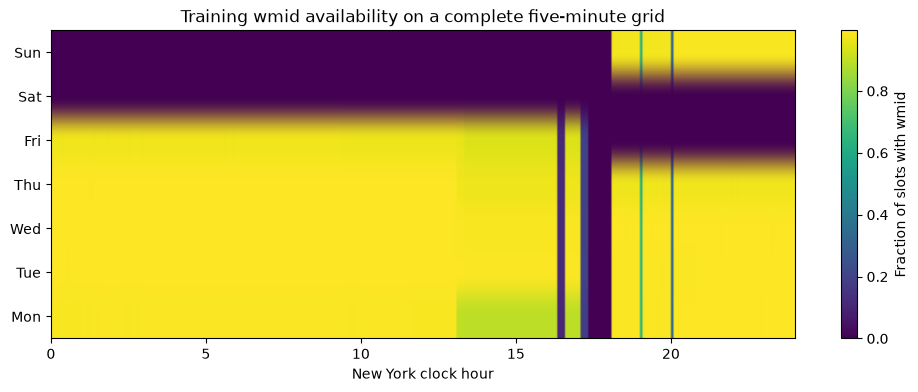

,Before close change,After close change,After pause removal
16:15,0.957528,0.956146,0.959731
16:20,0.000000,0.000000,0.959731
16:30,0.000000,0.000000,0.959731
16:35,0.957528,0.956146,0.959731
17:00,0.957528,0.956146,0.959731
17:05,0.957528,0.000000,0.000000
17:15,0.957528,0.000000,0.000000
17:20,0.000000,0.000000,0.000000
18:00,0.000000,0.000000,0.000000
18:05,0.788789,0.788704,0.792593


wmid_present,False,True
scheduled_trading_bar,,
False,40674,51
True,3107,596902


,session_diagnostics
training_rows,640734
scheduled_open_instants,600009
scheduled_trading_bars,600009
quotes_present,596953
missing_quotes_in_scheduled_bars,3107
quotes_outside_scheduled_bars,51


Dates with the most quotes outside the schedule (audit, not automatic relabeling):


,rows
2014-07-03,3
2014-11-28,3
2014-12-24,3
2015-11-27,3
2015-12-24,3
2016-11-25,3
2017-07-03,3
2017-11-24,3
2018-07-03,3
2018-11-23,3


SESSION_DIAGNOSTICS
training_rows                       640734
scheduled_open_instants             600009
scheduled_trading_bars              600009
quotes_present                      596953
missing_quotes_in_scheduled_bars      3107
quotes_outside_scheduled_bars           51
ERA_AVAILABILITY
       Before close change  After close change  After pause removal
16:15             0.957528            0.956146             0.959731
16:20             0.000000            0.000000             0.959731
16:30             0.000000            0.000000             0.959731
16:35             0.957528            0.956146             0.959731
17:00             0.957528            0.956146             0.959731
17:05             0.957528            0.000000             0.000000
17:15             0.957528            0.000000             0.000000
17:20             0.000000            0.000000             0.000000
18:00             0.000000            0.000000             0.000000
18:05             0.78878

In [4]:
from takehome.sessions import is_tradable as es_is_tradable, es_schedule, availability_by_week

weekly_availability = availability_by_week(df['wmid'])
weekly = weekly_availability['has_wmid'].unstack('weekday').reindex(columns=range(7))
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(weekly.T, aspect='auto', origin='lower', extent=(0, 24, -.5, 6.5))
ax.set_yticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
ax.set_xlabel('New York clock hour'); ax.set_title('Training wmid availability on a complete five-minute grid')
fig.colorbar(im, ax=ax, label='Fraction of slots with wmid'); plt.show(); plt.close('all')

# A single pooled weekly rule would hide historical changes.
era_profiles = {}
for name, start, end in [('Before close change', '2014-01-01', '2015-09-20'),
                          ('After close change', '2015-09-21', '2021-06-27'),
                          ('After pause removal', '2021-06-28', '2022-07-14')]:
    q = df.loc[start:end, 'wmid']
    p = availability_by_week(q)
    era_profiles[name] = p.loc[p.index.get_level_values('weekday') < 5, 'has_wmid'].groupby('minute').mean()
boundaries = [16*60+15,16*60+20,16*60+30,16*60+35,17*60,17*60+5,17*60+15,17*60+20,18*60,18*60+5,19*60,20*60]
era_availability = pd.DataFrame(era_profiles).reindex(boundaries)
era_availability.index = [f'{m//60:02d}:{m%60:02d}' for m in boundaries]
display(era_availability)

is_tradable = es_is_tradable(df.index)
is_trading_bar = es_is_tradable(df.index, bar_end=True)
quote_available = df['wmid'].notna()
display(pd.crosstab(is_trading_bar.rename('scheduled_trading_bar'), quote_available.rename('wmid_present')))
session_diagnostics = pd.Series({
    'training_rows': len(df), 'scheduled_open_instants': int(is_tradable.sum()),
    'scheduled_trading_bars': int(is_trading_bar.sum()), 'quotes_present': int(quote_available.sum()),
    'missing_quotes_in_scheduled_bars': int((is_trading_bar & ~quote_available).sum()),
    'quotes_outside_scheduled_bars': int((~is_trading_bar & quote_available).sum()),
}, name='session_diagnostics')
display(session_diagnostics.to_frame())
calendar_mismatches = df.loc[~is_trading_bar & quote_available, ['wmid']]
print('Dates with the most quotes outside the schedule (audit, not automatic relabeling):')
display(calendar_mismatches.groupby(calendar_mismatches.index.date).size().nlargest(12).to_frame('rows'))
print('SESSION_DIAGNOSTICS'); print(session_diagnostics.to_string())
print('ERA_AVAILABILITY'); print(era_availability.to_string())

### Calendar audit and use

The recurring isolated missing slot around 19:00 winter / 20:00 summer New York corresponds to midnight UTC and looks like a data-production artifact, not a CME maintenance interval. Do not train an exchange calendar by treating every recurring NaN as a market closure.

The mask is defined for later fitting/execution workflows and can be generated without future prices. Existing standalone P&Ls and the ad hoc combination below are deliberately **not silently filtered** by this newly introduced mask, so their definitions remain comparable. To impose trading restrictions later, apply the schedule at the trade-decision/label interval, with explicit bar-label and fill conventions. The calendar is a scheduled-open model, not a guarantee of executable liquidity.

## 1. Scatter matrix

Nine representative feature columns are shown for readability, using **all their training observations**. Missing pairs are omitted by the plotting routine; rows are not sampled. The all-feature correlation matrix below covers all feature pairs.

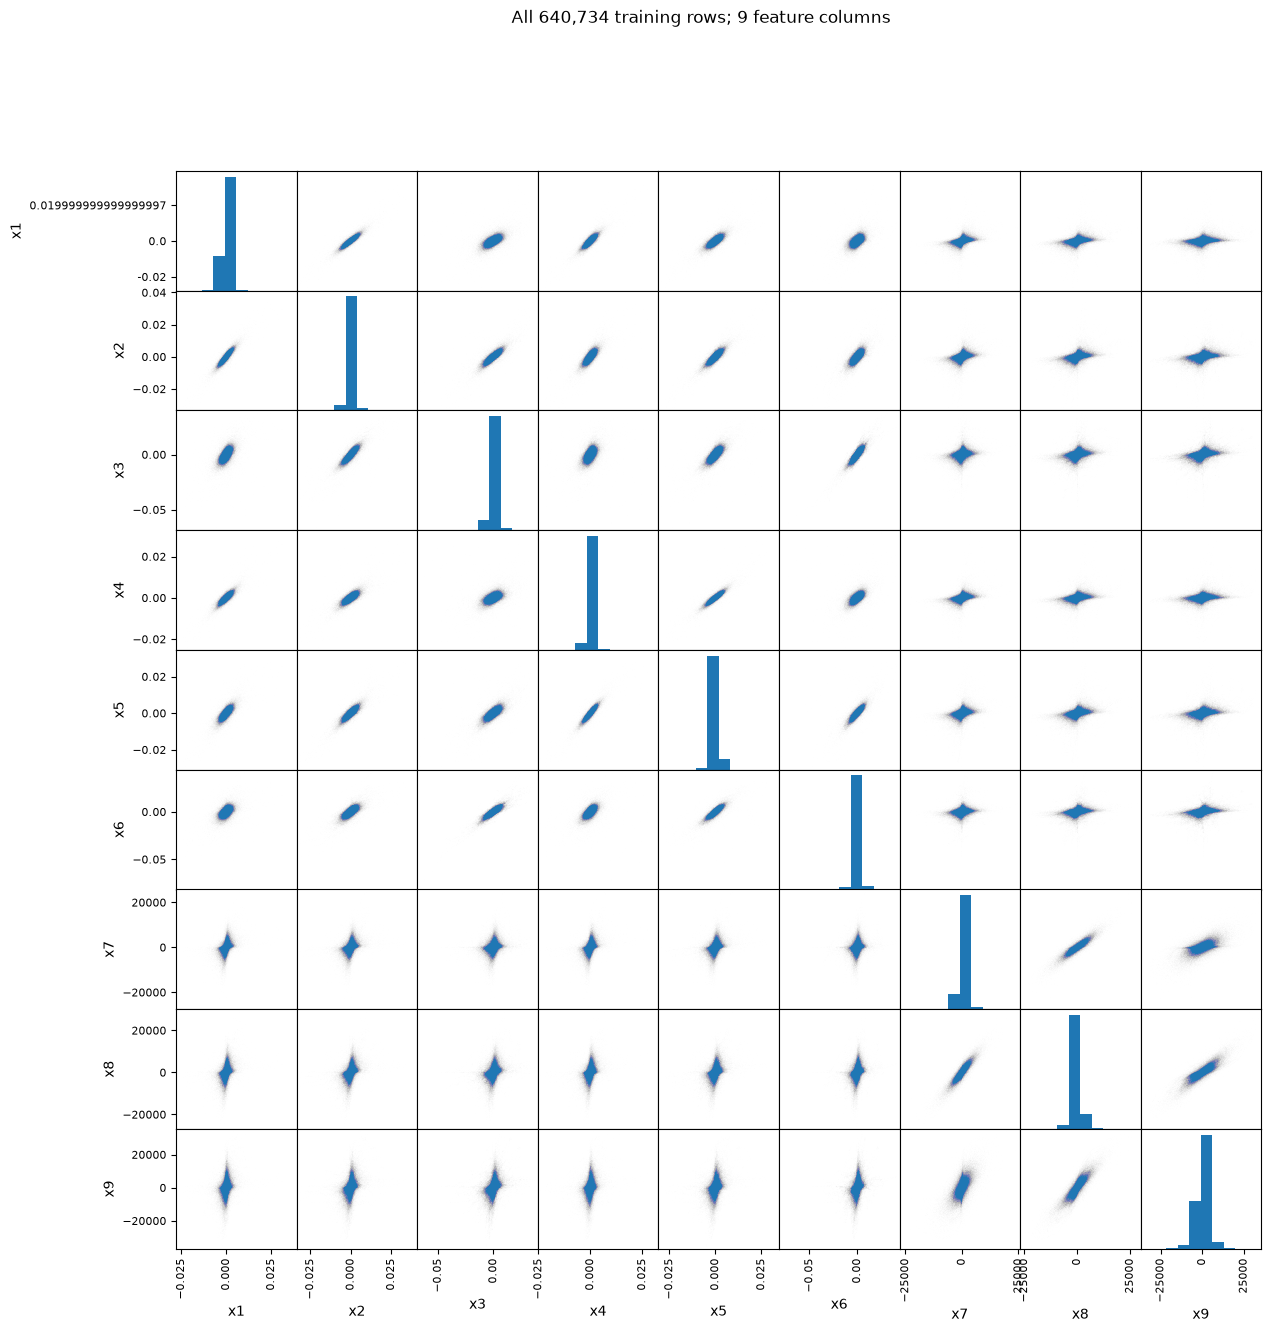

In [5]:
scatter_features = [c for c in feature_cols if df[c].nunique() > 1][:SCATTER_N_FEATURES]
scatter_matrix(df[scatter_features], figsize=(14, 14), diagonal='hist',
               alpha=.08, s=.2, rasterized=True)
plt.suptitle(f'All {len(df):,} training rows; {len(scatter_features)} feature columns', y=.995)
plt.show()
plt.close('all')

## 2. Distribution-shape screen and return sanity check

No Gaussianity test. The full-sample screen flags a dip statistic above 0.01, absolute Bowley quartile skew above 0.25, an exact point mass above 10%, or fewer than 20 unique values. These are practical degeneracy thresholds, not calibrated hypothesis tests; a pass does not prove a bell shape. High kurtosis is deliberately allowed.

Using the [Hartigan dip statistic](https://github.com/RUrlus/diptest) rather than its iid p-value avoids both a sample cap and interpreting tiny large-sample departures as useful rejections. Serially dependent features are not iid.

`adjMid.pct_change(fill_method=None)` is a contemporaneous sanity check. The supplied `ret_5m` is also reported separately; its alignment is not assumed to match that price change. All values and sample counts below are training-only.

,feature,n,nunique,max_mass,robust_skew,dip_stat,bell_like
6,x7,346261,345026,0.002940,0.065775,inf,False
68,x69,9126,9126,0.000110,-0.019220,0.002129,True
66,x67,9126,9126,0.000110,-0.012363,0.001646,True
67,x68,9126,9126,0.000110,-0.059021,0.001637,True
11,x12,16560,16560,0.000060,-0.036038,0.001600,True
...,...,...,...,...,...,...,...
56,x57,480744,480744,0.000002,-0.010753,0.000172,True
58,x59,338841,338841,0.000003,0.024714,0.000165,True
40,x41,446749,446749,0.000002,-0.029800,0.000164,True
54,x55,480744,480744,0.000002,0.037573,0.000145,True


Pass shape screen: 99/100; flagged: 1


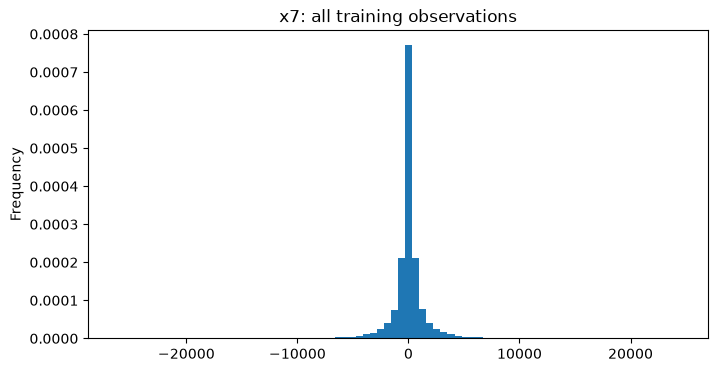

,feature,pearson,pearson_p,spearman,spearman_p,n,pearson_q,spearman_q,max_abs_corr
60,x61,0.415557,0.000000e+00,0.350083,0.000000e+00,168937,0.000000e+00,0.000000e+00,0.415557
57,x58,-0.411100,0.000000e+00,-0.337529,0.000000e+00,338832,0.000000e+00,0.000000e+00,0.411100
42,x43,0.381231,0.000000e+00,0.313393,0.000000e+00,168935,0.000000e+00,0.000000e+00,0.381231
36,x37,0.351904,0.000000e+00,0.295867,0.000000e+00,168823,0.000000e+00,0.000000e+00,0.351904
45,x46,0.345192,0.000000e+00,0.282360,0.000000e+00,99355,0.000000e+00,0.000000e+00,0.345192
99,x100,0.077271,0.000000e+00,0.337293,0.000000e+00,584307,0.000000e+00,0.000000e+00,0.337293
33,x34,0.332063,0.000000e+00,0.264749,0.000000e+00,161112,0.000000e+00,0.000000e+00,0.332063
9,x10,0.286760,6.345562e-311,0.328594,0.000000e+00,16560,1.379470e-310,0.000000e+00,0.328594
66,x67,0.321950,4.098448e-219,0.314194,3.150248e-208,9126,7.881631e-219,6.429077e-208,0.321950
51,x52,0.319535,0.000000e+00,0.285254,0.000000e+00,167411,0.000000e+00,0.000000e+00,0.319535


Top correlations to supplied ret_5m (not assumed contemporaneous):


,feature,pearson,pearson_p,spearman,spearman_p,n,pearson_q,spearman_q,max_abs_corr
57,x58,0.018288,1.831179e-26,0.025212,9.105777e-49,338777,1.831179e-24,9.105777e-47,0.025212
6,x7,-0.001722,3.108236e-01,-0.023301,8.598336e-43,346205,4.257858e-01,2.149584e-41,0.023301
9,x10,-0.007924,3.078746e-01,-0.021978,4.678876e-03,16560,4.257858e-01,8.507047e-03,0.021978
39,x40,-0.001265,3.978454e-01,-0.021057,5.449059e-45,446673,5.113141e-01,1.816353e-43,0.021057
33,x34,-0.020514,1.799257e-16,-0.016435,4.186711e-11,161114,5.997525e-15,2.462771e-10,0.020514
54,x55,-0.000528,7.141038e-01,-0.020364,2.843706e-45,480723,7.761998e-01,1.421853e-43,0.020364
12,x13,-0.003123,2.229217e-01,-0.019904,7.865186e-15,152348,3.483151e-01,7.048631e-14,0.019904
15,x16,-0.002247,3.805279e-01,-0.019792,1.111916e-14,152348,5.006947e-01,8.553199e-14,0.019792
60,x61,-0.018851,9.356760e-15,-0.018883,8.458357e-15,168885,1.871352e-13,7.048631e-14,0.018883
34,x35,-0.018762,5.022619e-14,-0.007524,2.527138e-03,161114,8.371031e-13,4.768185e-03,0.018762


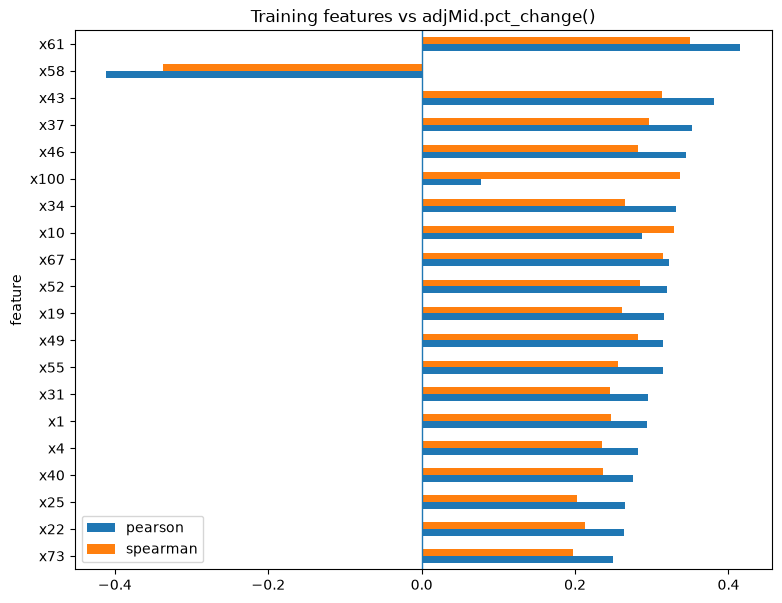

In [6]:
shape = bell_shape_table(df, feature_cols)
flagged_shape = shape.loc[~shape.bell_like]
display(shape)
print(f'Pass shape screen: {shape.bell_like.sum()}/{len(shape)}; flagged: {len(flagged_shape)}')
assert shape.set_index('feature')['n'].reindex(feature_cols).eq(df[feature_cols].count()).all()
for col in flagged_shape.feature.head(6):
    df[col].plot.hist(bins=80, density=True, figsize=(8, 4), title=f'{col}: all training observations')
    plt.show()
    plt.close('all')

df['_ret1'] = df.adjMid.pct_change(fill_method=None)
return_corr = correlation_to_column(df, '_ret1', feature_cols)
provided_corr = correlation_to_column(df, 'ret_5m', feature_cols)
strong_target = return_corr.loc[return_corr.max_abs_corr >= .10]
display(strong_target)
print('Top correlations to supplied ret_5m (not assumed contemporaneous):')
display(provided_corr.head(15))
return_corr.head(20).sort_values('max_abs_corr').plot.barh(
    x='feature', y=['pearson', 'spearman'], figsize=(9, 7),
    title='Training features vs adjMid.pct_change()')
plt.axvline(0, linewidth=1)
plt.show()
plt.close('all')

## 3. Feature correlation and dendrogram

Cluster using distance $1-|\rho_S|$ so strongly positive and strongly negative variants are grouped together. The heatmap retains signed Spearman correlation.

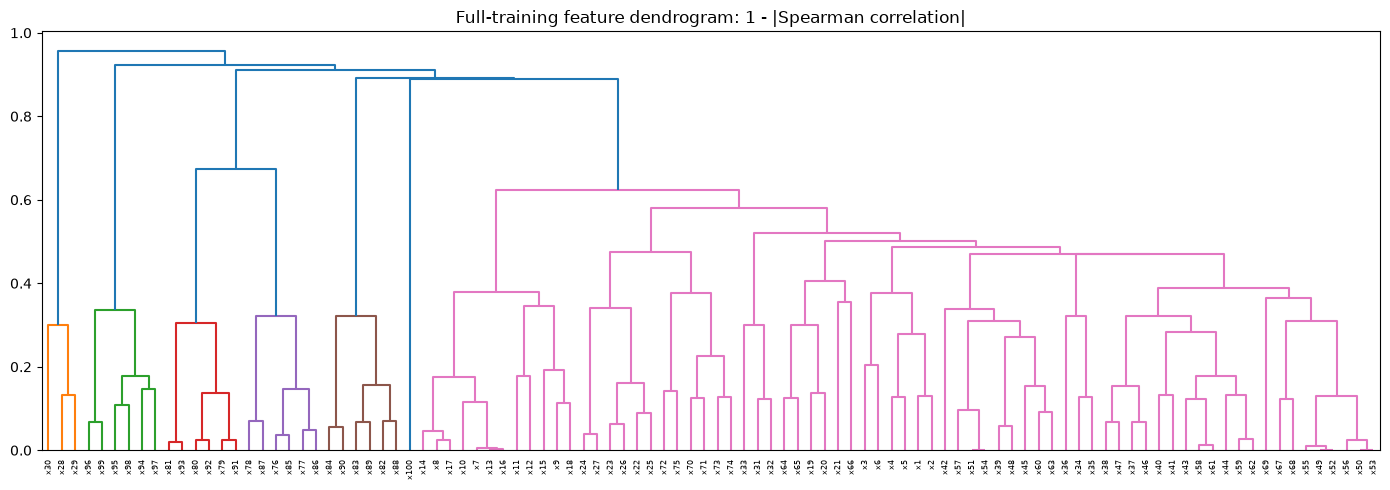

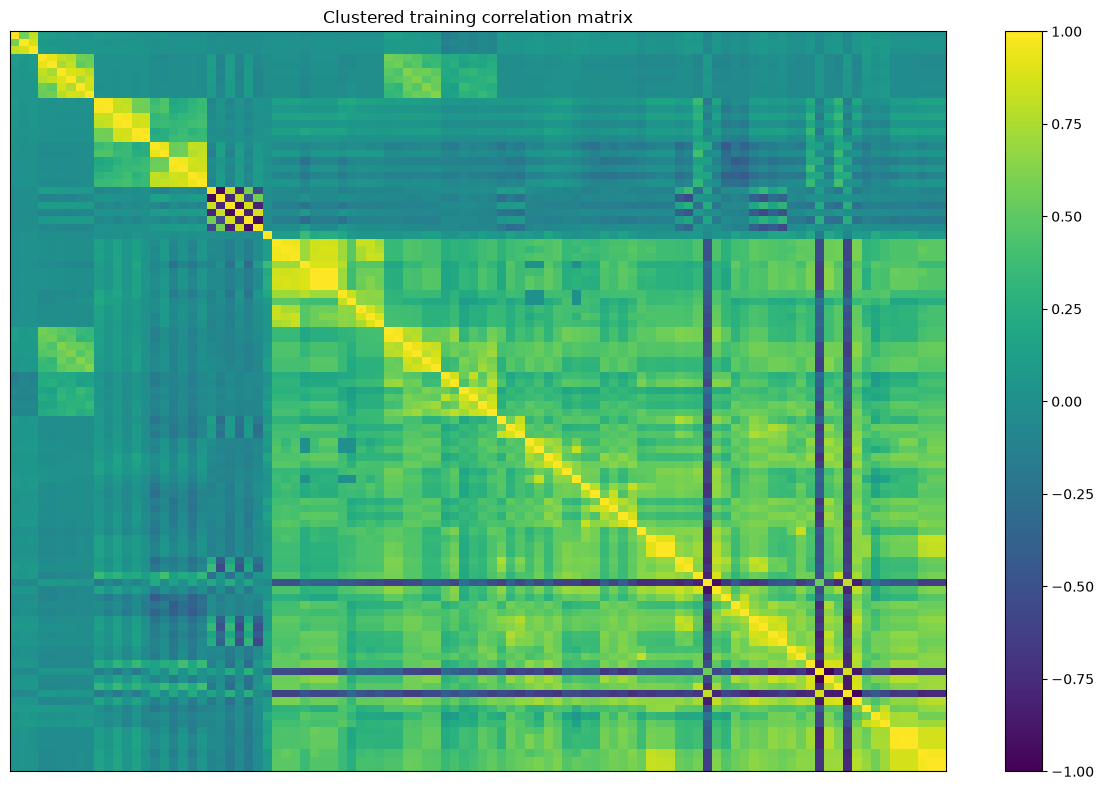

,feature1,feature2,corr,abs_corr,index_gap
0,x49,x52,0.999996,0.999996,3
1,x50,x53,0.999857,0.999857,3
2,x51,x54,0.999642,0.999642,3
3,x13,x16,0.997249,0.997249,3
4,x7,x16,0.994874,0.994874,9
5,x7,x13,0.994009,0.994009,6
6,x49,x55,0.988759,0.988759,6
7,x52,x55,0.988740,0.988740,3
8,x58,x61,-0.987044,0.987044,3
9,x81,x93,0.981349,0.981349,12


,n_pairs,median_abs_corr,p90_abs_corr,frac_gt_080
index_gap,,,,
1,99,0.818790,0.872724,0.636364
3,97,0.629066,0.940188,0.226804
2,98,0.558137,0.766949,0.071429
6,94,0.491680,0.841372,0.106383
30,70,0.482820,0.578557,0.000000
12,88,0.477858,0.717065,0.034091
9,91,0.471795,0.782792,0.098901
21,79,0.459784,0.630910,0.037975
33,67,0.453791,0.604650,0.000000


,count,mean,median
same_mod3,,,
False,3333,0.279061,0.276361
True,1617,0.340687,0.369206


In [7]:
corr, z, order = correlation_clustering(df, feature_cols, method='spearman')
plt.figure(figsize=(14, 5))
dendrogram(z, labels=feature_cols, leaf_rotation=90, leaf_font_size=6)
plt.title('Full-training feature dendrogram: 1 - |Spearman correlation|')
plt.tight_layout()
plt.show()
plt.close('all')
heatmap(corr.loc[order, order], 'Clustered training correlation matrix', labels=False, limits=(-1, 1))
plt.close('all')
upper = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
pairs = redundant_pairs(corr, threshold=.8)
display(pairs.head(30))
gap_pairs = pairs.dropna(subset=['index_gap']).copy()
gap_pairs['index_gap'] = gap_pairs.index_gap.astype(int)
all_pairs = redundant_pairs(corr, threshold=0).dropna(subset=['index_gap'])
all_pairs['index_gap'] = all_pairs.index_gap.astype(int)
gap_summary = all_pairs.groupby('index_gap').agg(
    n_pairs=('abs_corr', 'size'), median_abs_corr=('abs_corr', 'median'),
    p90_abs_corr=('abs_corr', lambda x: x.quantile(.9)),
    frac_gt_080=('abs_corr', lambda x: (x >= .8).mean()),
).sort_values('median_abs_corr', ascending=False)
all_pairs['same_mod3'] = all_pairs.index_gap.mod(3).eq(0)
mod3_summary = all_pairs.groupby('same_mod3').abs_corr.agg(['count', 'mean', 'median'])
display(gap_summary.head(20), mod3_summary)

## 4. Full-training autocorrelation

Ljung–Box(15) is applied directly to each feature, not regression residuals. Display and rank raw statistics, ACF(1), and per-feature observation counts; Q also grows with sample size. Missing values are omitted per feature: these are lags between successive observed values, not guaranteed five-minute clock intervals.

,feature,n,acf1,max_abs_acf_1_to_lag,lb_stat,lb_pvalue,lb_qvalue
56,x57,480744,0.989220,0.989220,4.578699e+06,0.0,0.0
41,x42,446749,0.989065,0.989065,4.307341e+06,0.0,0.0
65,x66,374281,0.988780,0.988780,3.650854e+06,0.0,0.0
77,x78,338776,0.990617,0.990617,3.395004e+06,0.0,0.0
5,x6,329833,0.987226,0.987226,3.214314e+06,0.0,0.0
2,x3,333875,0.987453,0.987453,3.203368e+06,0.0,0.0
59,x60,338841,0.986322,0.986322,3.135615e+06,0.0,0.0
8,x9,346261,0.976988,0.976988,2.935727e+06,0.0,0.0
55,x56,480744,0.963029,0.963029,2.612777e+06,0.0,0.0
40,x41,446749,0.963445,0.963445,2.431948e+06,0.0,0.0


Usable features: 100/100
Ljung-Box(15), FDR q<5%: 100/100


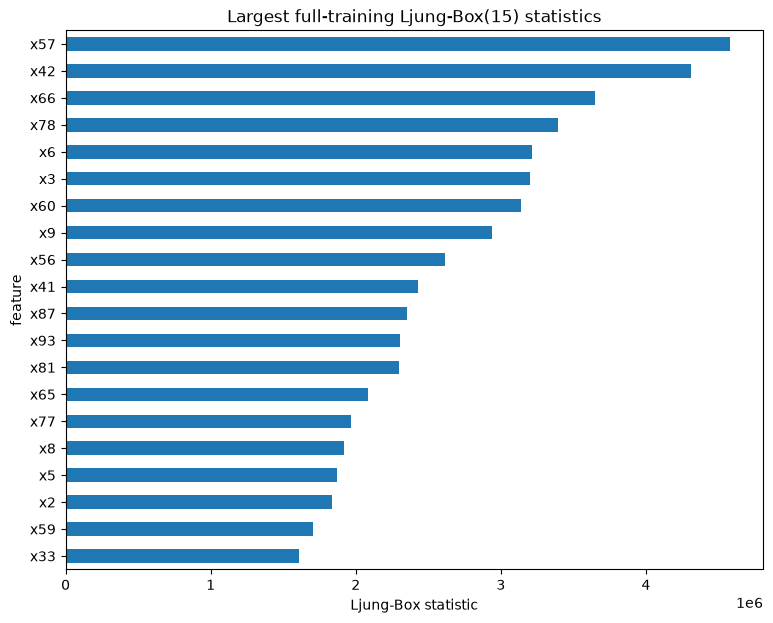

In [8]:
auto = autocorrelation_table(df, feature_cols, lag=ACF_LAG)
assert auto.set_index('feature')['n'].reindex(feature_cols).eq(df[feature_cols].count()).all()
display(auto.head(20))
print(f'Usable features: {auto.lb_stat.notna().sum()}/{len(auto)}')
print(f'Ljung-Box({ACF_LAG}), FDR q<5%: {(auto.lb_qvalue < .05).sum()}/{len(auto)}')
auto.head(20).sort_values('lb_stat').plot.barh(
    x='feature', y='lb_stat', figsize=(9, 7), legend=False,
    title=f'Largest full-training Ljung-Box({ACF_LAG}) statistics')
plt.xlabel('Ljung-Box statistic')
plt.show()
plt.close('all')

### 4.1 Longer-lag / seasonal ACF patterns

Repeated bands or peaks in the heatmap flag periodic structure. These are **row lags**: if source bars have gaps, lag 288 is not automatically a 24-hour clock-time lag.

,peak_lag,peak_acf
x30,16,0.624285
x18,16,0.618594
x78,16,0.607077
x87,16,0.605638
x33,16,0.591339
x6,16,0.591328
x84,16,0.589893
x93,16,0.589365
x66,16,0.588983
x81,16,0.585701


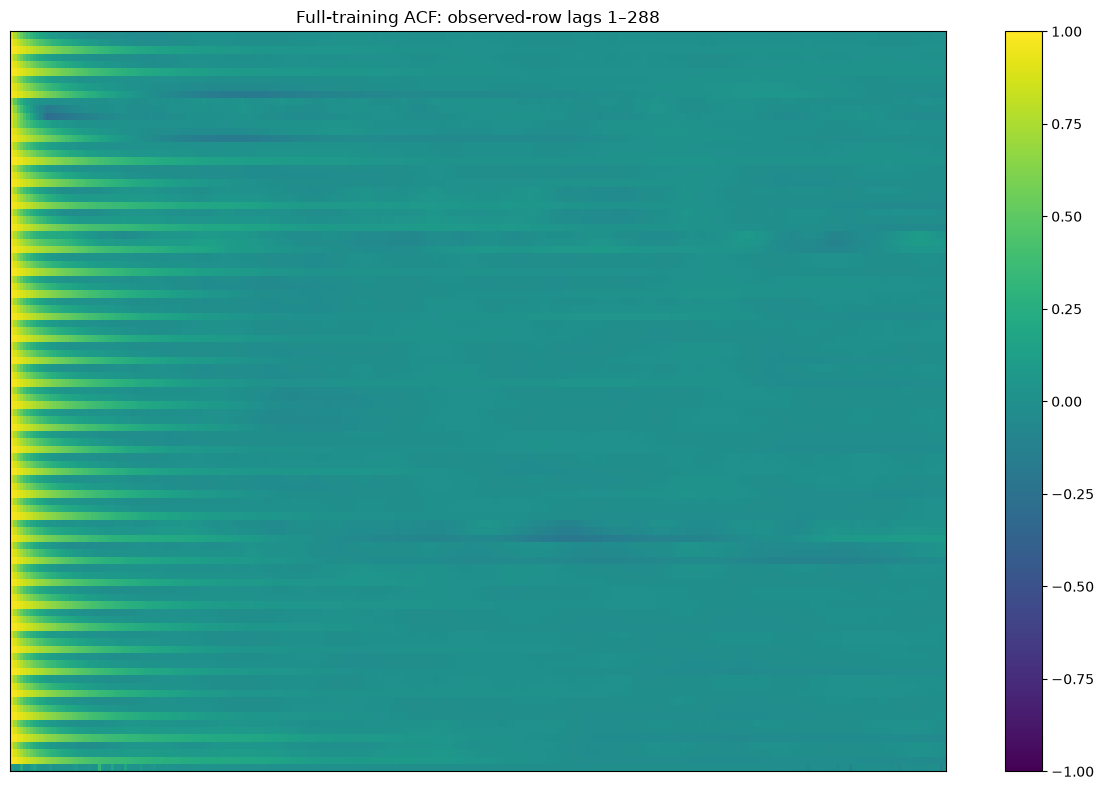

In [9]:
season_acf = acf_matrix(df, feature_cols, nlags=SEASONAL_NLAGS)
long_lag = season_acf.loc[ACF_LAG + 1:]
valid = long_lag.columns[long_lag.notna().any()]
peak_lag = long_lag[valid].abs().idxmax()
peak = pd.DataFrame({
    'peak_lag': peak_lag,
    'peak_acf': [long_lag.loc[peak_lag[c], c] for c in valid],
}).sort_values('peak_acf', key=lambda s: s.abs(), ascending=False)
display(peak.head(20))
heatmap(season_acf.loc[1:].T, 'Full-training ACF: observed-row lags 1–288', labels=False, limits=(-1, 1))
plt.close('all')

## 5. Training-period distribution shifts

Adjacent-month mean changes are scaled by the **training** standard deviation. The log standard-deviation ratio compares adjacent months. These are descriptive changes, not formal break-date estimates. All grouping now uses `msgStamp`; partial boundary months can have fewer observations.

,max_abs_monthly_mean_shift_z,max_abs_monthly_log_std_ratio
x27,1.194728,1.544659
x24,1.163821,1.561496
x99,1.127276,1.652901
x96,1.091659,1.706036
x30,1.075000,2.899247
x33,1.064781,1.325685
x39,1.005112,1.154962
x63,0.966948,1.200168
x36,0.896158,1.049421
x29,0.888844,2.891253


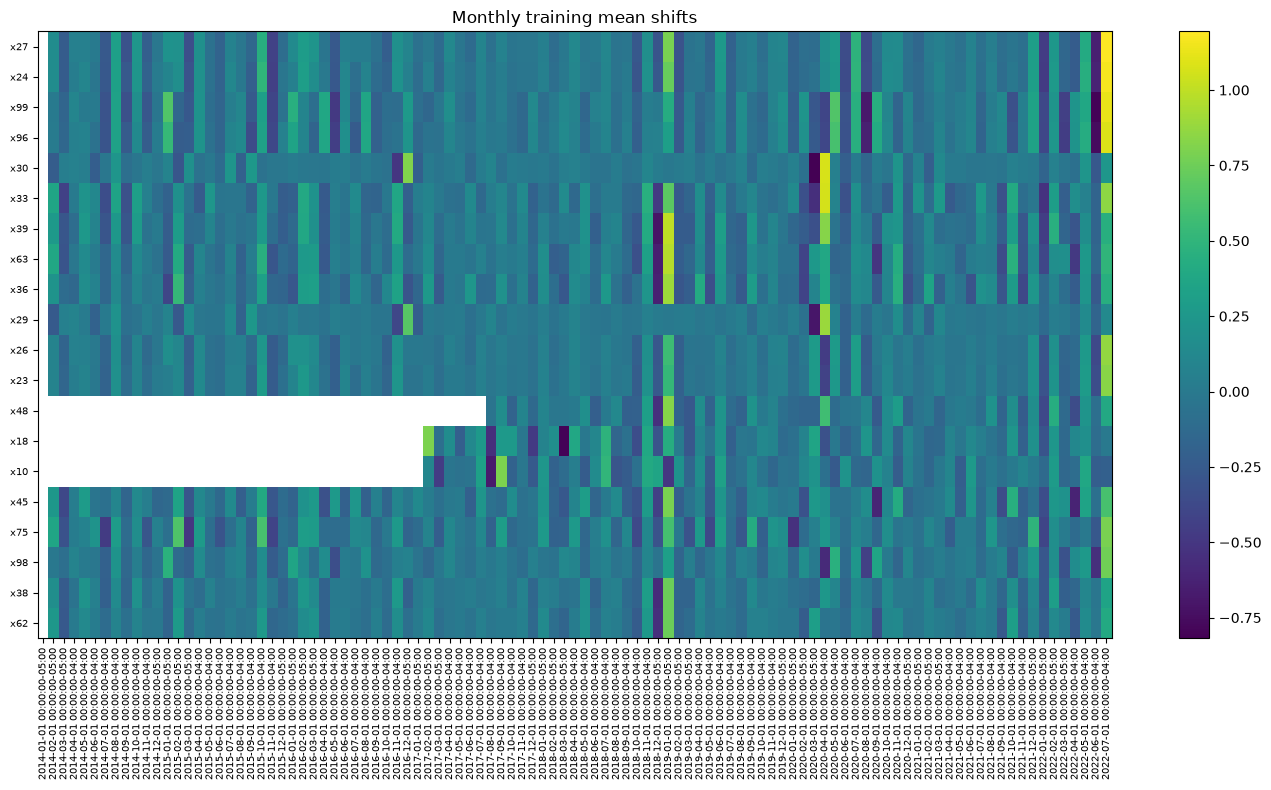

In [10]:
mean_shift, vol_shift = monthly_shift_scores(df.reset_index(), 'msgStamp', feature_cols)
breaks = pd.DataFrame({
    'max_abs_monthly_mean_shift_z': mean_shift.abs().max(),
    'max_abs_monthly_log_std_ratio': vol_shift.abs().max(),
}).sort_values('max_abs_monthly_mean_shift_z', ascending=False)
display(breaks.head(20))
heatmap(mean_shift[breaks.head(20).index].T, 'Monthly training mean shifts', figsize=(14, 8))
plt.close('all')

## 6. Cashflow: infer the definition from named fields

Only named numeric market variables are compared; `x*` features are deliberately excluded. Examine cashflow relative to volume as well as unconditional level correlations.

,wmid,adjMid,volume,cashflow,ret_5m
wmid,1.000000,0.999182,0.052109,0.008949,0.002637
adjMid,0.999182,1.000000,0.054724,0.008655,0.002669
volume,0.052109,0.054724,1.000000,-0.013539,0.008276
cashflow,0.008949,0.008655,-0.013539,1.000000,-0.016442
ret_5m,0.002637,0.002669,0.008276,-0.016442,1.000000


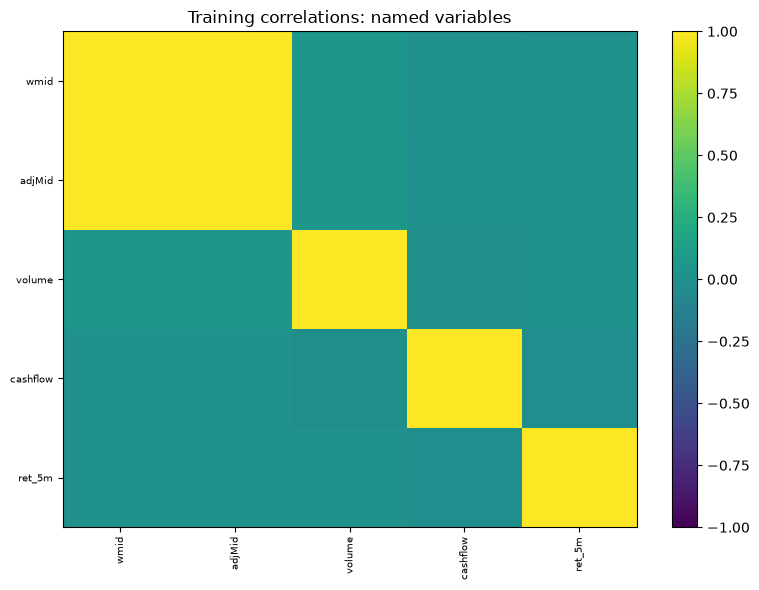

,spearman
adjMid,0.008655
wmid,0.008949
volume,-0.013539
ret_5m,-0.016442


In [11]:
named_numeric = [c for c in df.select_dtypes(include=np.number).columns
                 if c not in feature_cols and not c.startswith('_')]
named_corr = df[named_numeric].corr(method='spearman')
display(named_corr)
heatmap(named_corr, 'Training correlations: named variables', figsize=(8, 6), limits=(-1, 1))
plt.close('all')
cash_named = named_corr['cashflow'].drop('cashflow').sort_values(key=lambda x: x.abs()).to_frame('spearman')
display(cash_named)

### Cashflow-to-volume exceptions

Show rows where `abs(cashflow / volume) > 1`. Zero volume is not silently discarded: nonzero cashflow divided by zero appears as infinity and is included by this predicate. Display a deterministic sample of at most 20 rows, followed by all distinct dates and their exception counts. Only the display is sampled; the predicate and counts use every training row. No CSV is exported.

In [12]:
flow_ratio = df.cashflow / df.volume
cashflow_outliers = df.loc[flow_ratio.abs().gt(1), named_numeric].assign(cashflow_per_volume=flow_ratio)
print(f'{len(cashflow_outliers):,} / {len(df):,} training rows have |cashflow / volume| > 1')
print(f'Zero-volume rows: {df.volume.eq(0).sum():,}')
display(cashflow_outliers.sample(n=min(20, len(cashflow_outliers)), random_state=0).sort_index())
exception_dates = cashflow_outliers.groupby(cashflow_outliers.index.date).size().rename('exception_rows')
print(f'{len(exception_dates)} unique local dates; counts below cover ALL exceptions, not the sample.')
with pd.option_context('display.max_rows', None):
    display(exception_dates.to_frame())

551 / 640,734 training rows have |cashflow / volume| > 1
Zero-volume rows: 6,471


,wmid,adjMid,volume,cashflow,ret_5m,cashflow_per_volume
msgStamp,,,,,,
2014-06-17 16:50:00-04:00,1934.220064,2130.867951,27.0,-67.0,0.000000,-2.481481
2014-09-15 02:25:00-04:00,1970.387755,2179.424142,56.0,-73.0,0.000254,-1.303571
2014-09-16 22:55:00-04:00,1990.565287,2201.824010,112.0,-119.0,-0.000126,-1.062500
2014-09-17 01:20:00-04:00,1990.176295,2201.547468,12.0,17.0,-0.000126,1.416667
2014-09-17 23:55:00-04:00,1994.661082,2206.525217,38.0,39.0,-0.000125,1.026316
2015-06-16 19:15:00-04:00,2089.641304,2337.265800,50.0,-55.0,-0.000120,-1.100000
2016-12-14 01:40:00-05:00,2266.662963,2595.787951,34.0,-78.0,-0.000110,-2.294118
2017-06-15 01:25:00-04:00,2430.087766,2788.970317,92.0,-105.0,-0.000206,-1.141304
2018-09-18 00:35:00-04:00,2893.045918,3303.185874,140.0,148.0,0.000173,1.057143


92 unique local dates; counts below cover ALL exceptions, not the sample.


,exception_rows
2014-03-17,4
2014-03-18,4
2014-03-19,2
2014-03-20,1
2014-03-21,2
2014-06-15,4
2014-06-16,15
2014-06-17,10
2014-06-18,5
2014-06-19,5


## Transform experiments

The following backtests share the same declared `SIGNAL_RULE`, all research rows and the existing daily aggregation convention. We first compare raw signals and time-of-day scaling, then raw pair products/residuals, and finally a one-row oracle and causal alpha-forecast controls. Keeping these related experiments together separates descriptive feature research from the later joint Ridge/Lasso validation.

Parameters are predeclared, not picked to maximize these plots. Products and directed residuals use every pair in small column batches. No displayed P&L is clipped: the **exposure** is bounded before multiplication by returns. Coverage and the maximum exposure are retained for each candidate, so the absence of numerical explosions can be checked rather than inferred from a rescaled axis.


### Signed-flow diagnostic, with the shared signal-only sizing

Cashflow may represent signed trade flow or imbalance rather than unsigned price-times-volume; its definition is not documented here. Out-of-range `cashflow/volume` can also reflect aggregation, unit or timestamp mismatches.

For this descriptive control only, clip that ratio to [-1,1], then apply the **same lagged, floored, capped signal normalizer** as every other main backtest. Unlike the old flow curve, no realized-return volatility enters its sizing. The un-clipped ratio remains x100 in the model. Return timing and execution assumptions still require verification.


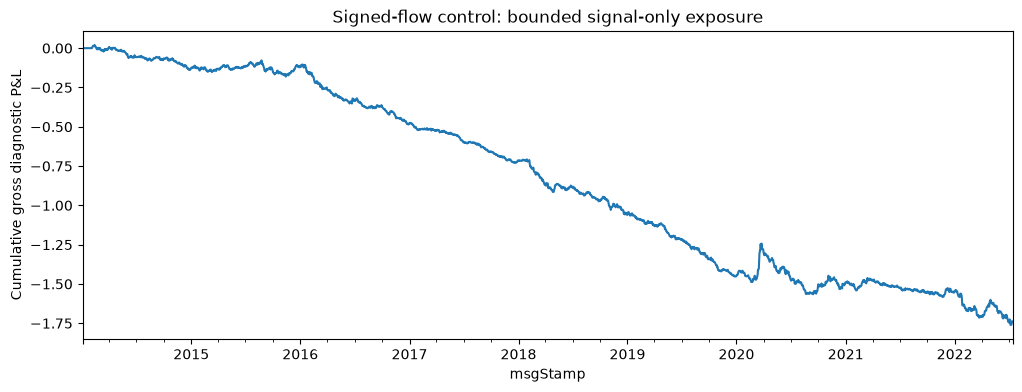

In [13]:
from takehome.features import backtest
flow_signal = df.cashflow.div(df.volume.replace(0, np.nan)).clip(-1, 1)
flow_contribution = backtest(flow_signal, df.ret_5m, HL, normalization=SIGNAL_RULE)
flow_cumulative = flow_contribution.resample('D').sum().cumsum()
flow_cumulative.plot(figsize=(12,4), title='Signed-flow control: bounded signal-only exposure')
plt.ylabel('Cumulative gross diagnostic P&L'); plt.show(); plt.close('all')


### Standalone feature importance

Each raw signal is evaluated independently with `SIGNAL_RULE`: lagged signal standard deviation, a past-only floor, and an explicit absolute exposure cap of 3. These are **standalone research diagnostics**, not incremental feature importance or an executable net-return backtest. No sign is chosen by looking at full-period outcomes.

All 100 x columns and every research row are used, in eight-column batches. The family panel includes a gross-normalized, one-row-lagged EWM-Sharpe combination. Its own right-hand axis has an independent scale. Raw-family meta scores are clipped below at zero; transformed families retain signed scores. Daily histograms report unannualized calendar-day mean/std. Warm-up and differing coverage are reported, not silently filled with tradable predictions.


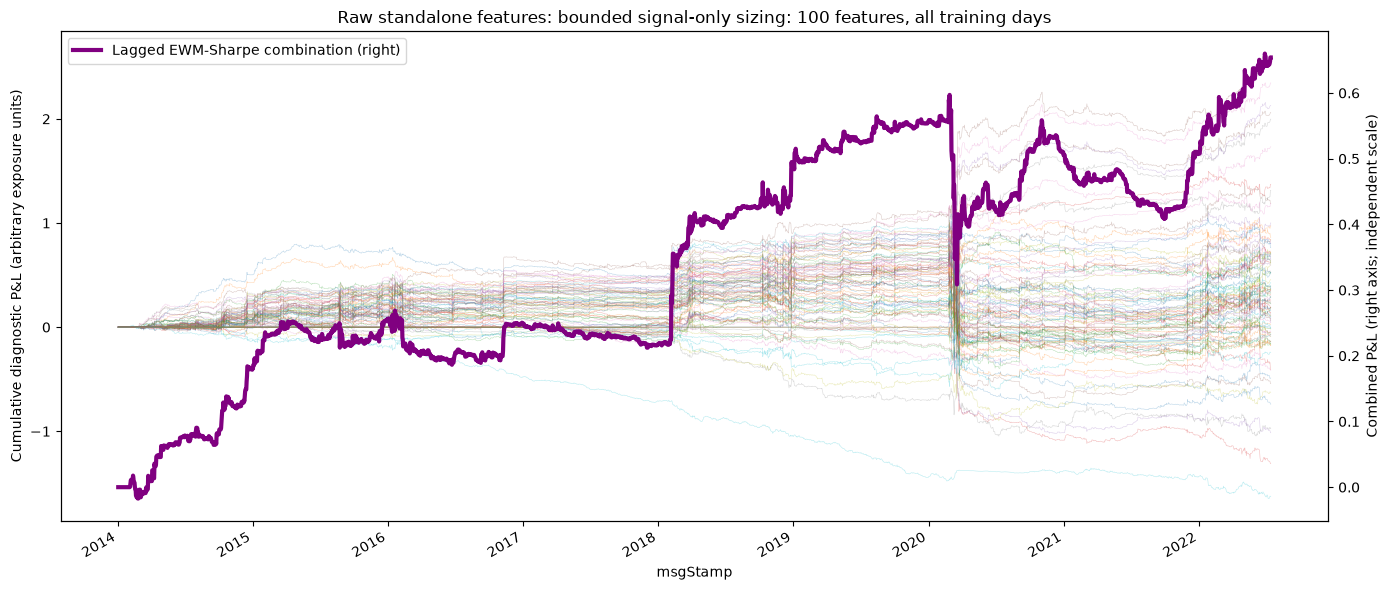

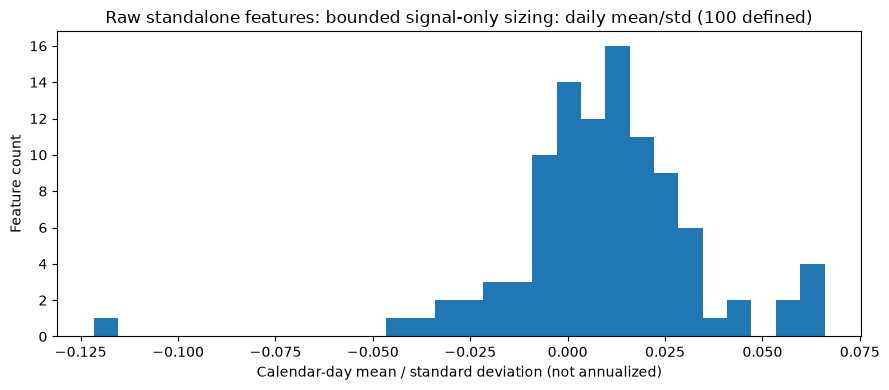

x1      0.022450
x2      0.026244
x3      0.020703
x4     -0.010983
x5      0.001387
          ...   
x96     0.028727
x97     0.042411
x98     0.024687
x99     0.024649
x100   -0.121648
Length: 100, dtype: float64

In [14]:
from functools import partial
from takehome import features as feature_ops
from takehome.features import ts_std, ts_standardize, ts_zscore, sharpe, combine_pnls
from takehome.plots import display_results
# Explicit notebook policy; no global monkey-patching of feature helpers.
evaluate_features = partial(feature_ops.evaluate_features, normalization=SIGNAL_RULE)
raw_blocks = (df[x_cols[j:j+BATCH_SIZE]] for j in range(0, len(x_cols), BATCH_SIZE))
pnl_daily, standalone, raw_meta = evaluate_features(
    raw_blocks, df.ret_5m, hl=HL, meta=True, meta_hl=META_HL, positive_only=True)
assert standalone.max_abs_weight.max() <= SIGNAL_RULE['cap']
display_results(pnl_daily, 'Raw standalone features: bounded signal-only sizing',
                meta_daily=raw_meta.resample('D').sum())


In [15]:
with pd.option_context('display.max_rows', None):
    display(standalone)
print('Standalone daily mean/std range:', standalone.daily_mean_over_std.min(), standalone.daily_mean_over_std.max())
print('Largest raw-feature exposure:', standalone.max_abs_weight.max())


,daily_mean_over_std,pnl_observations,days_with_observations,first_pnl_msgStamp,last_pnl_msgStamp,max_abs_weight,capped_fraction
x76,0.065944,332666,2163,2014-02-26 12:05:00-05:00,2022-07-13 16:00:00-04:00,3.000000,0.019055
x85,0.062096,228875,2145,2014-03-24 07:05:00-04:00,2022-07-13 16:00:00-04:00,3.000000,0.018704
x86,0.062035,228875,2145,2014-03-24 07:05:00-04:00,2022-07-13 16:00:00-04:00,3.000000,0.017966
x77,0.061200,332666,2163,2014-02-26 12:05:00-05:00,2022-07-13 16:00:00-04:00,3.000000,0.018757
x87,0.059069,228875,2145,2014-03-24 07:05:00-04:00,2022-07-13 16:00:00-04:00,3.000000,0.015948
x78,0.057041,332666,2163,2014-02-26 12:05:00-05:00,2022-07-13 16:00:00-04:00,3.000000,0.016951
x94,0.046554,153522,2064,2014-04-29 12:20:00-04:00,2022-07-13 16:00:00-04:00,3.000000,0.017548
x97,0.042411,147765,2058,2014-05-07 12:00:00-04:00,2022-07-13 16:00:00-04:00,3.000000,0.018387
x58,0.037774,332731,2163,2014-02-26 12:05:00-05:00,2022-07-13 16:00:00-04:00,3.000000,0.019297
x95,0.034551,153522,2064,2014-04-29 12:20:00-04:00,2022-07-13 16:00:00-04:00,3.000000,0.018284


Standalone daily mean/std range: -0.1216482783790075 0.06594448917792016
Largest raw-feature exposure: 3.0


### Forecasts, positions and evaluation have different units

A return forecast is not a position. The old inverse-variance rule turned a smaller-magnitude forecast into a larger position: replacing $s$ by $cs$ divides $s/\sigma_s^2$ by $c$. The fixed first-scale multiplier used in the normalization control removes this dependence on measurement units, but leaves that individual curve's jump concentration unchanged.

The selected position rule instead uses one power of signal standard deviation, an anchored floor and a visible cap. It needs no prices during the final blackout and keeps signs without demeaning the signal. This is **signal standardization**, not asset-volatility targeting. Model training weights are a separate decision; weighted residual fitting does not automatically create these positions.


In [16]:
from time import perf_counter
from takehome.features import dszl, pairwise_features, combine_pnls
raw_features = df[x_cols]
experiment_seconds = {}
assert raw_features.index.equals(df.index) and df.index.max() < split['cutoff']


### Time-of-day standardization — dszl(hl=10)

Apply `ts_standardize` **inside each local clock-time group**, then restore chronological order. There is no demeaning. Ten observations means ten nonzero observations at that clock time, not ten adjacent bars. The current feature value is known and included in its scale; no target enters the transform.

The displayed family strategies subsequently use the same 6,048-observation signal-only exposure rule. For the joint model later, the input is this **dszl feature**, not its position or P&L. Its group state continues across train/forecast boundaries and throughout the label blackout; it is never refitted on future labels. Only after transformation are undefined model inputs zero-imputed.


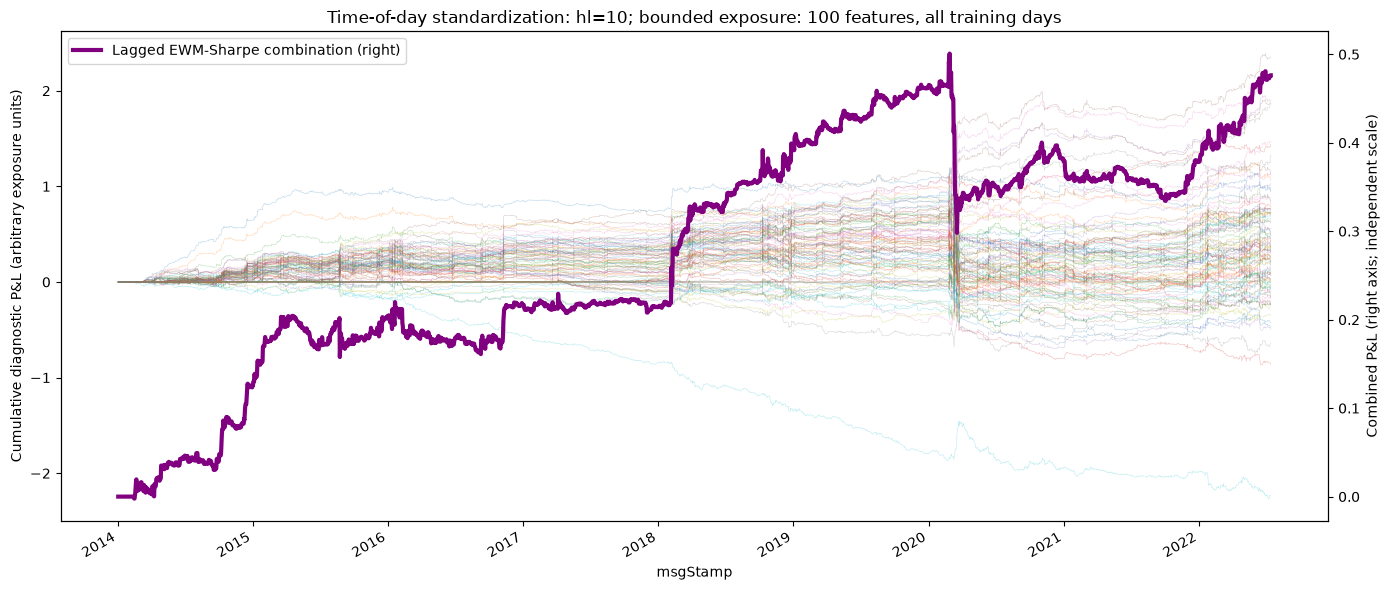

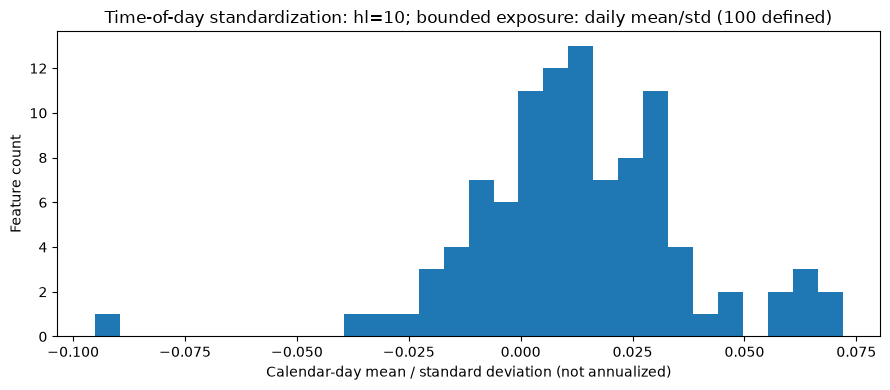

,daily_mean_over_std,pnl_observations,days_with_observations,first_pnl_msgStamp,last_pnl_msgStamp,max_abs_weight,capped_fraction
x76,0.071931,331262,2154,2014-03-11 14:05:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.005629
x77,0.069463,331262,2154,2014-03-11 14:05:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.005514
x86,0.066129,227903,2136,2014-04-04 07:05:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.004992
x85,0.066003,227903,2136,2014-04-04 07:05:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.005097
x78,0.064304,331262,2154,2014-03-11 14:05:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.004968
x94,0.058437,152820,2055,2014-05-12 14:50:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.006969
x87,0.056869,227903,2136,2014-04-04 07:05:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.004049
x97,0.048970,147063,2047,2014-05-22 10:45:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.007684
x58,0.045351,331327,2154,2014-03-11 14:05:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.008703
x95,0.043325,152820,2055,2014-05-12 14:50:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.006086


In [17]:
started = perf_counter()
dszl_blocks = (dszl(raw_features.iloc[:, j:j+BATCH_SIZE], hl=DSZL_HL)
               for j in range(0, len(x_cols), BATCH_SIZE))
dszl_daily, dszl_summary, dszl_meta = evaluate_features(
    dszl_blocks, df.ret_5m, hl=HL, meta=True, meta_hl=META_HL)
experiment_seconds['dszl(10)'] = perf_counter() - started
assert dszl_daily.shape[1] == len(x_cols) and dszl_summary.max_abs_weight.max() <= SIGNAL_RULE['cap']
display_results(dszl_daily, 'Time-of-day standardization: hl=10; bounded exposure',
                meta_daily=dszl_meta.resample('D').sum())
display(dszl_summary.head(10))


### Two-way interactions — products of distinct raw features

Use $z_{ij,t}=x_{i,t}x_{j,t}$ for every $i<j$: **4,950 products** for 100 predictors. Squares and duplicate reverse-order products are excluded. These are raw products, not products of the dszl signals and not demeaned products. Missing either input makes the product missing. The following P&L scaling uses the **product's own** lagged EWM standard deviation, floor and cap.

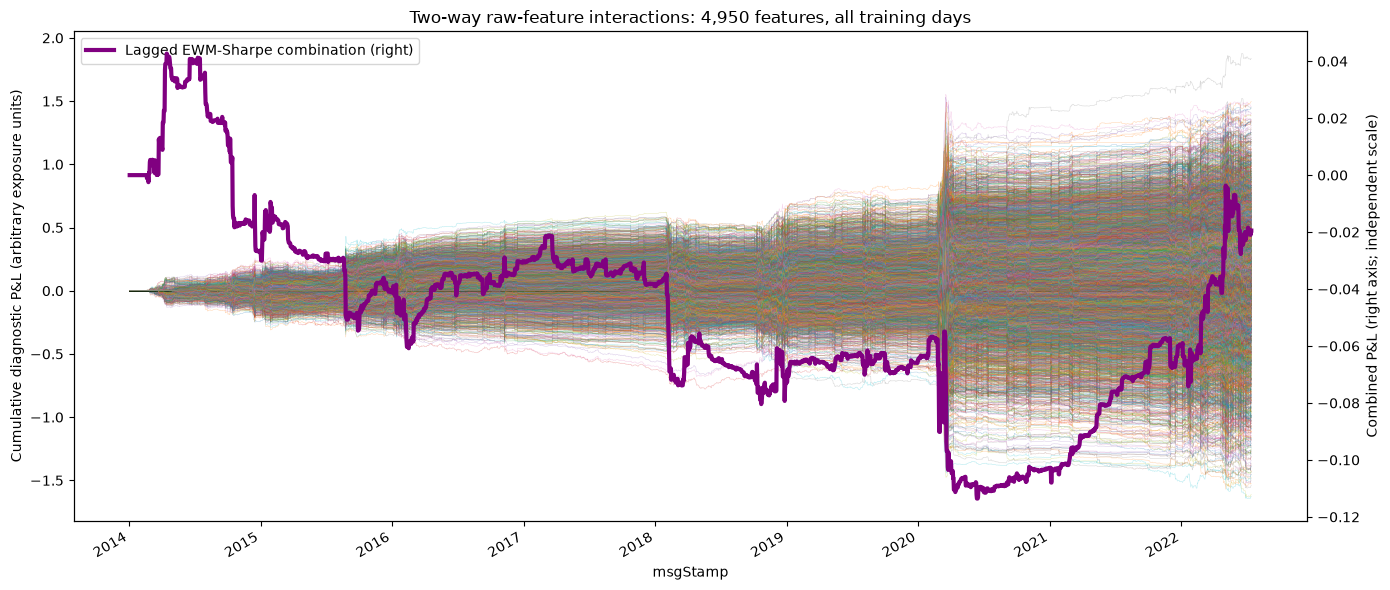

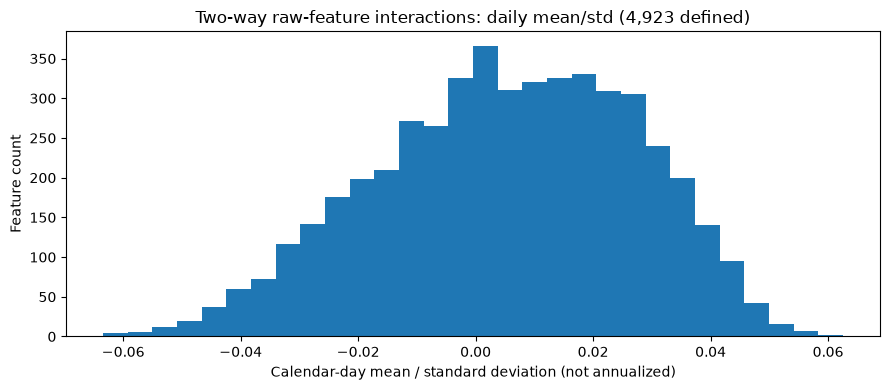

Top 10 of all distinct products; this is a training screen, not feature selection.


,daily_mean_over_std,pnl_observations,days_with_observations,first_pnl_msgStamp,last_pnl_msgStamp,max_abs_weight,capped_fraction
x39*x72,0.062537,149408,2058,2014-05-07 12:35:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.022683
x60*x78,0.058728,332666,2163,2014-02-26 12:05:00-05:00,2022-07-13 16:00:00-04:00,3.0,0.017432
x33*x72,0.057276,148950,2058,2014-05-07 15:25:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.020638
x54*x72,0.056794,148960,2054,2014-05-07 12:35:00-04:00,2022-07-13 15:55:00-04:00,3.0,0.021563
x51*x72,0.056200,148960,2054,2014-05-07 12:35:00-04:00,2022-07-13 15:55:00-04:00,3.0,0.021401
x32*x72,0.055626,148950,2058,2014-05-07 15:25:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.019060
x70*x100,0.054575,149408,2058,2014-05-07 12:45:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.019370
x21*x52,0.054209,157343,2062,2014-04-25 15:40:00-04:00,2022-07-13 15:55:00-04:00,3.0,0.018107
x21*x49,0.054194,157343,2062,2014-04-25 15:40:00-04:00,2022-07-13 15:55:00-04:00,3.0,0.018119
x51*x71,0.053427,148960,2054,2014-05-07 12:35:00-04:00,2022-07-13 15:55:00-04:00,3.0,0.018609


In [18]:
started = perf_counter()
interaction_daily, interaction_summary, interaction_meta = evaluate_features(
    pairwise_features(raw_features, kind='product', batch_size=8),
    df['ret_5m'], hl=HL, meta=True, meta_hl=META_HL,
)
experiment_seconds['Raw products'] = perf_counter() - started
assert interaction_daily.shape[1] == len(x_cols) * (len(x_cols) - 1) // 2
display_results(interaction_daily, 'Two-way raw-feature interactions',
                meta_daily=interaction_meta.resample('D').sum())
print('Top 10 of all distinct products; this is a training screen, not feature selection.')
display(interaction_summary.head(10))
assert interaction_summary.max_abs_weight.max() <= SIGNAL_RULE['cap']


### Pairwise residuals — online lasso with alpha=0, W=1

Use both directions for every pair: **9,900 residual series**. The name `x_i~x_j` means the residual of raw `x_i` regressed on raw `x_j`, with an intercept. Its reverse is a different experiment.

The existing `StreamingWeightedLasso` is used with `n_features=1`, `alpha=0` (the implementation's regularization parameter), `fit_intercept=True`, and `decay=2**(-1/6048)`. Each jointly finite pair receives unit observation weight; missing rows receive zero weight but still advance the original row clock. No price, return or notional weights enter these regressions.

For a residual at row $t$, fit only earlier jointly observed raw pairs:

$$ (a_{t-1},b_{t-1})=\arg\min_{a,b}\sum_{s<t}d^{t-1-s}I_s(x_{i,s}-a-bx_{j,s})^2,$$
$$z_{i\mid j,t}=x_{i,t}-a_{t-1}-b_{t-1}x_{j,t}.$$

Require two prior joint observations; the downstream P&L still needs 6,048 nonzero residual observations and a prior-row scale. The shifted coefficient/intercept histories ensure the current response does not fit away its own residual. This differs from using post-update/in-sample regression residuals. It removes the historical relationship with **one** other predictor, not all predictors jointly.

For one predictor and `alpha=0`, the fitter uses the exact scalar solution $b=C_{xy}/C_{xx}$, $a=\bar y-b\bar x$, from the same weighted centered sufficient statistics. This is a fast path inside the existing fitter, not an approximate substitute or a separate estimator. Tests reconcile it with direct weighted least squares and the previous coordinate-descent path, including skipped rows, intercepts, and pre-update timing.

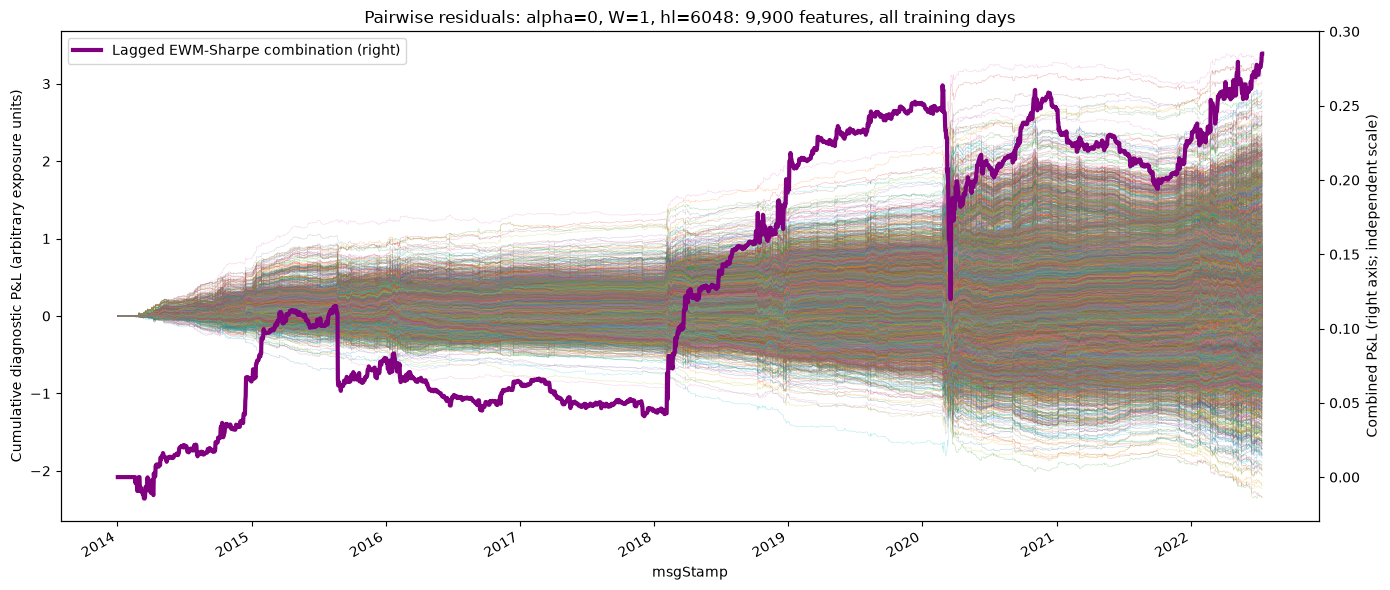

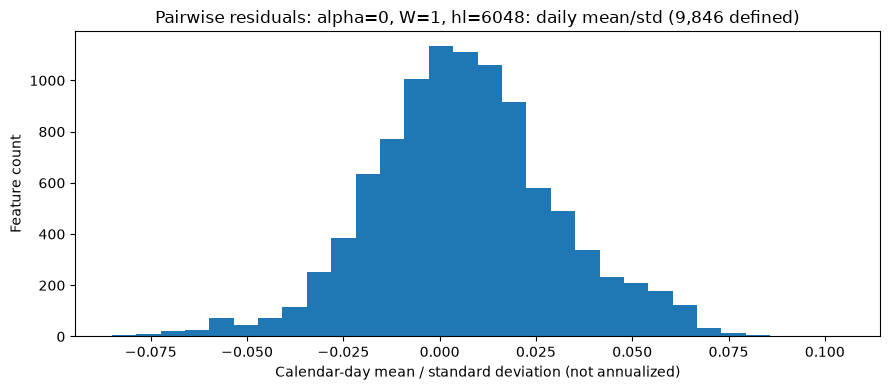

Top 10 of both directed residuals; near-collinear pairs require numerical caution.


,daily_mean_over_std,pnl_observations,days_with_observations,first_pnl_msgStamp,last_pnl_msgStamp,max_abs_weight,capped_fraction
x2~x58,0.104822,327769,2130,2014-02-26 12:15:00-05:00,2022-07-13 16:00:00-04:00,3.0,0.013788
x1~x58,0.099084,327769,2130,2014-02-26 12:15:00-05:00,2022-07-13 16:00:00-04:00,3.0,0.013053
x58~x2,0.097277,327769,2130,2014-02-26 12:15:00-05:00,2022-07-13 16:00:00-04:00,3.0,0.016869
x58~x1,0.091372,327769,2130,2014-02-26 12:15:00-05:00,2022-07-13 16:00:00-04:00,3.0,0.016466
x2~x34,0.087373,153014,2030,2014-05-07 15:35:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.014829
x44~x58,0.086180,162835,2121,2014-04-23 15:45:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.015139
x58~x41,0.084395,283801,2013,2014-03-20 05:20:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.017016
x19~x61,0.082134,157795,2066,2014-04-25 15:50:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.013194
x44~x61,0.080953,162835,2121,2014-04-23 15:45:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.015127
x58~x40,0.080773,283801,2013,2014-03-20 05:20:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.016096


In [19]:
started = perf_counter()
residual_daily, residual_summary, residual_meta = evaluate_features(
    pairwise_features(raw_features, kind='residual', hl=HL, batch_size=8),
    df['ret_5m'], hl=HL, meta=True, meta_hl=META_HL,
)
experiment_seconds['Pair residuals'] = perf_counter() - started
assert residual_daily.shape[1] == len(x_cols) * (len(x_cols) - 1)
display_results(residual_daily, 'Pairwise residuals: alpha=0, W=1, hl=6048',
                meta_daily=residual_meta.resample('D').sum())
print('Top 10 of both directed residuals; near-collinear pairs require numerical caution.')
display(residual_summary.head(10))
assert residual_summary.max_abs_weight.max() <= SIGNAL_RULE['cap']


### Training-only transformation comparison

Raw and dszl families have 100 candidates; products and directed residuals have 4,950 and 9,900. More trials create more opportunities for a good-looking research result. Compare the distributions and coverage, not only the maximum daily mean/std. All exposures are dimensionless and capped under the same rule, although nonlinear transformations still have different turnover and risk. This is not a claim of incremental or out-of-sample improvement.


In [20]:
experiment_summaries = {
    'Raw baseline': standalone, 'dszl(10)': dszl_summary,
    'Raw products': interaction_summary, 'Pair residuals': residual_summary,
}
comparison_rows = {}
for name, table in experiment_summaries.items():
    s = table['daily_mean_over_std'].dropna()
    comparison_rows[name] = {
        'candidates': len(table), 'defined_sharpes': len(s),
        'median_daily_sharpe': s.median(), 'p95_daily_sharpe': s.quantile(.95),
        'max_daily_sharpe': s.max(), 'min_daily_sharpe': s.min(),
        'positive_fraction': s.gt(0).mean(), 'compute_seconds': experiment_seconds.get(name, np.nan),
    }
transformation_comparison = pd.DataFrame.from_dict(comparison_rows, orient='index')
display(transformation_comparison)
print(transformation_comparison.to_string())
print('Train-only rows:', len(df), '; final training timestamp:', df.index.max())
for name, table in experiment_summaries.items():
    print('\n', name, 'top 5 (training diagnostics)')
    print(table.head(5).to_string())
assert len(df) == split['train_rows'] and df.index.max() < split['cutoff']
assert all(table.max_abs_weight.max() <= SIGNAL_RULE['cap'] for table in experiment_summaries.values())


,candidates,defined_sharpes,median_daily_sharpe,p95_daily_sharpe,max_daily_sharpe,min_daily_sharpe,positive_fraction,compute_seconds
Raw baseline,100,100,0.010576,0.057142,0.065944,-0.121648,0.700000,NaN
dszl(10),100,100,0.012430,0.058730,0.071931,-0.095206,0.740000,13.877793
Raw products,4950,4923,0.006091,0.038810,0.062537,-0.063409,0.604916,321.495907
Pair residuals,9900,9846,0.005680,0.050639,0.104822,-0.085119,0.602783,818.176409


                candidates  defined_sharpes  median_daily_sharpe  p95_daily_sharpe  max_daily_sharpe  min_daily_sharpe  positive_fraction  compute_seconds
Raw baseline           100              100             0.010576          0.057142          0.065944         -0.121648           0.700000              NaN
dszl(10)               100              100             0.012430          0.058730          0.071931         -0.095206           0.740000        13.877793
Raw products          4950             4923             0.006091          0.038810          0.062537         -0.063409           0.604916       321.495907
Pair residuals        9900             9846             0.005680          0.050639          0.104822         -0.085119           0.602783       818.176409
Train-only rows: 640734 ; final training timestamp: 2022-07-14 00:30:00-04:00

 Raw baseline top 5 (training diagnostics)
     daily_mean_over_std  pnl_observations  days_with_observations        first_pnl_msgStamp         la

### Ad hoc lagged EWM-Sharpe combination summary

Estimate each component's score from its **intrabar diagnostic P&L**, not daily P&L:

$$s_{j,t}=\frac{\mathrm{EWMmean}(p_j)_t}{\mathrm{EWMstd}(p_j)_t},\quad
m_{j,t}=\frac{s_{j,t}}{\sum_k |s_{k,t}|},\quad
p_t^{\rm meta}=\sum_j m_{j,t-1}p_{j,t}.$$

Use `halflife=252*288 = 72576` rows and pandas default EWM warm-up. Clip negative scores only for the **raw baseline**; keep signed scores for dszl, products and residuals. Scores with zero/undefined volatility get zero allocation. A zero gross denominator means no position. This fixes the sketch's invalid `hl=` EWM keyword and makes row-wise normalization and the final sum across signals explicit.

```python
moments = ewm_observed(pnls, 252*288)
score = moments.mean().div(moments.std().replace(0, np.nan)).fillna(0)
# Raw signals only: score = score.clip(lower=0)
meta_w = score.div(score.abs().sum(axis=1).replace(0, np.nan), axis=0)
combined = meta_w.shift().mul(pnls).sum(axis=1)
combined.resample('D').sum().cumsum().plot()
```

Pair computations normalize across **all candidates**, not separately inside each eight-column batch. The additive lagged numerator/gross calculation is algebraically identical to the dense formula and is tested against it. Missing current P&L contributes zero without redistributing its previously chosen allocation. Missing values do not count as artificial zero observations when estimating EWM moments.

These are training-only, ad hoc combinations. There is no alpha-sign selection using the full sample, no cost model, no covariance adjustment, and no holdout access. One-row lag is adequate only if the component's preceding P&L is actually observable then; `ret_5m` label availability remains a separate contract. An in-sample adaptive baseline is not a validated out-of-sample Sharpe. The half-life is in rows, not exactly a calendar year.

The actual combined P&L is highlighted in purple in each corresponding family panel above. This section retains the numerical cross-family comparison; member exposures now share the same dimensionless cap; their realized risk and turnover still differ.

In [21]:
meta_pnls = pd.concat({
    'Raw (positive scores)': raw_meta, 'dszl(10) (signed)': dszl_meta,
    'Products (signed)': interaction_meta, 'Residuals (signed)': residual_meta,
}, axis=1)
assert meta_pnls.index.equals(df.index) and np.isfinite(meta_pnls.to_numpy()).all()
meta_daily = meta_pnls.resample('D').sum()
meta_summary = pd.DataFrame({
    'daily_mean_over_std': sharpe(meta_daily), 'daily_mean': meta_daily.mean(),
    'daily_std': meta_daily.std(), 'nonzero_bars': meta_pnls.ne(0).sum(),
    'cumulative_pnl': meta_daily.sum(),
})
display(meta_summary)
print('META_COMBINATIONS'); print(meta_summary.to_string())

,daily_mean_over_std,daily_mean,daily_std,nonzero_bars,cumulative_pnl
Raw (positive scores),0.039707,0.000210,0.005286,448455,0.653984
dszl(10) (signed),0.044814,0.000153,0.003411,489171,0.476286
Products (signed),-0.003717,-0.000006,0.001682,448365,-0.019482
Residuals (signed),0.036308,0.000091,0.002520,448363,0.285101


META_COMBINATIONS
                       daily_mean_over_std  daily_mean  daily_std  nonzero_bars  cumulative_pnl
Raw (positive scores)             0.039707    0.000210   0.005286        448455        0.653984
dszl(10) (signed)                 0.044814    0.000153   0.003411        489171        0.476286
Products (signed)                -0.003717   -0.000006   0.001682        448365       -0.019482
Residuals (signed)                0.036308    0.000091   0.002520        448363        0.285101


### Optimistic future-predictor diagnostic — h=1 only

Use `df[x_cols].shift(-1)` as the only look-ahead experiment. Keep **h=0 as a causal-input control**, not as another oracle horizon. This asks whether knowing the next predictor value could help; it is deliberately noncausal and is not an achievable backtest or a guarantee of a forecastable upper bound.

Shifts are applied only after the training split. Both control and oracle exclude the **last one target row** for a common endpoint, rather than discarding 24 rows. Leads count dataframe rows, not elapsed minutes across gaps. Feature missingness is reported separately. Both use the existing `evaluate_features` sizing and lagged EWM-Sharpe combination; no reserved-window targets enter the experiment.


#### Predictor lead h=0 — causal-input control

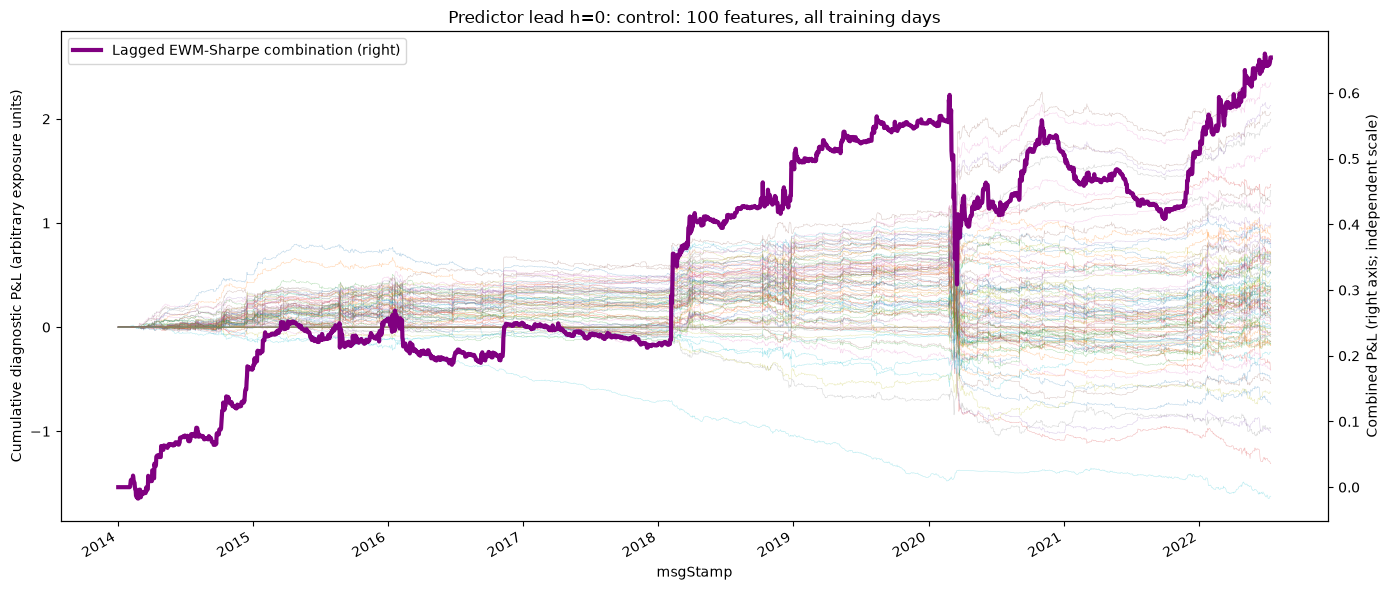

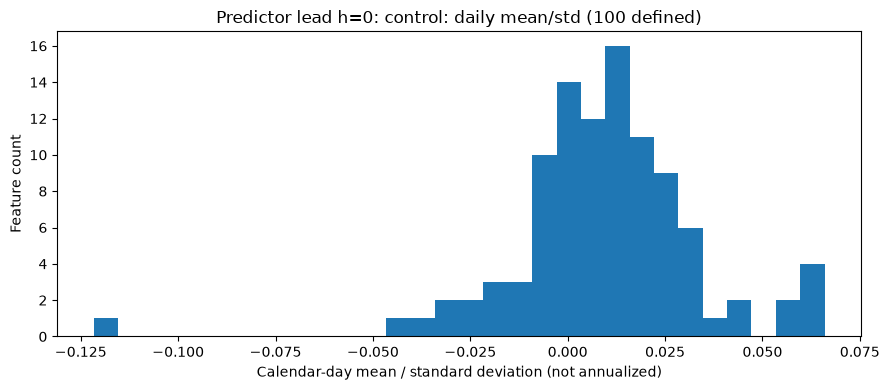

,daily_mean_over_std,pnl_observations,days_with_observations,first_pnl_msgStamp,last_pnl_msgStamp,max_abs_weight,capped_fraction
x76,0.065944,332666,2163,2014-02-26 12:05:00-05:00,2022-07-13 16:00:00-04:00,3.0,0.019055
x85,0.062096,228875,2145,2014-03-24 07:05:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.018704
x86,0.062035,228875,2145,2014-03-24 07:05:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.017966
x77,0.061200,332666,2163,2014-02-26 12:05:00-05:00,2022-07-13 16:00:00-04:00,3.0,0.018757
x87,0.059069,228875,2145,2014-03-24 07:05:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.015948
x78,0.057041,332666,2163,2014-02-26 12:05:00-05:00,2022-07-13 16:00:00-04:00,3.0,0.016951
x94,0.046554,153522,2064,2014-04-29 12:20:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.017548
x97,0.042411,147765,2058,2014-05-07 12:00:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.018387
x58,0.037774,332731,2163,2014-02-26 12:05:00-05:00,2022-07-13 16:00:00-04:00,3.0,0.019297
x95,0.034551,153522,2064,2014-04-29 12:20:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.018284


In [22]:
h = 0
oracle_returns = df.ret_5m.where(rows < len(df)-1)
blocks = (df[x_cols[start:start+8]].shift(-h) for start in range(0,len(x_cols),8))
oracle_daily, oracle_summary, oracle_meta = evaluate_features(
    blocks, oracle_returns, hl=HL, meta=True, meta_hl=META_HL, positive_only=True)
display_results(oracle_daily, f'Predictor lead h={h}: '+('control' if h==0 else 'LOOK-AHEAD'),
                meta_daily=oracle_meta.resample('D').sum())
if h==0:
    oracle_records, oracle_score_columns = [], {}
scores=oracle_summary.daily_mean_over_std
oracle_score_columns[h]=scores
oracle_records.append(dict(h=h, candidates=len(scores), defined=int(scores.notna().sum()),
    median_sharpe=scores.median(), p95_sharpe=scores.quantile(.95), best_sharpe=scores.max(),
    meta_sharpe=sharpe(oracle_meta.resample('D').sum()),
    median_pnl_observations=oracle_summary.pnl_observations.median()))
display(oracle_summary.head(10))


#### Predictor lead h=1 — LOOK-AHEAD

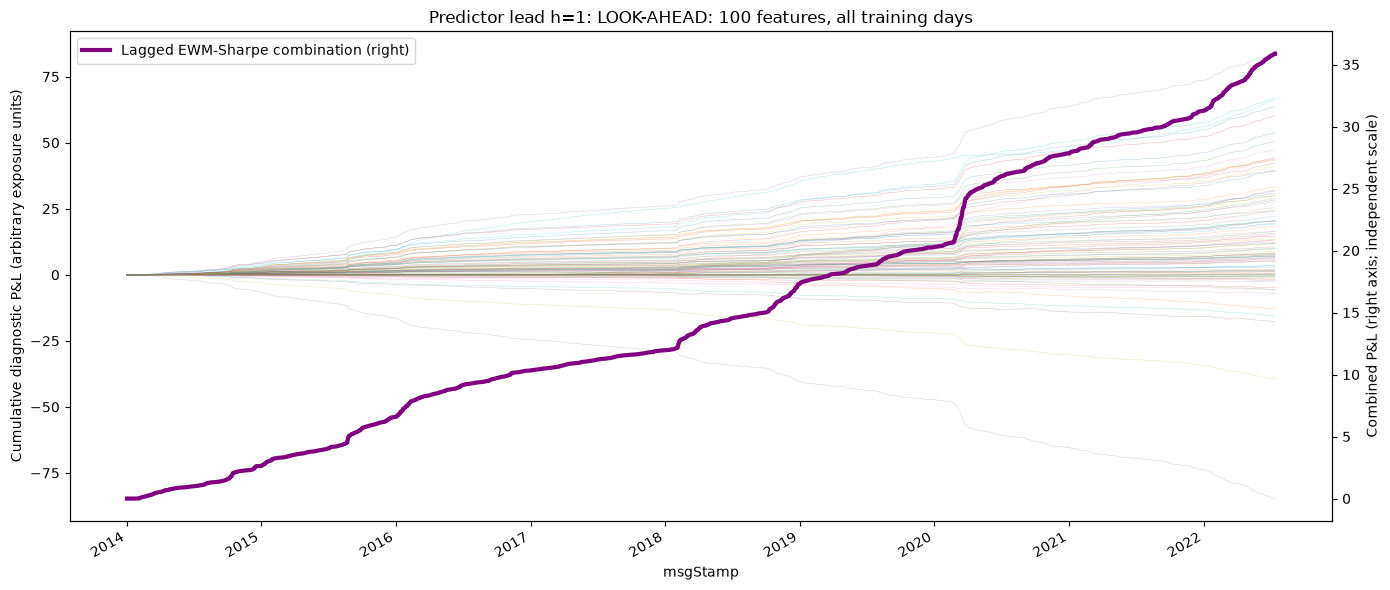

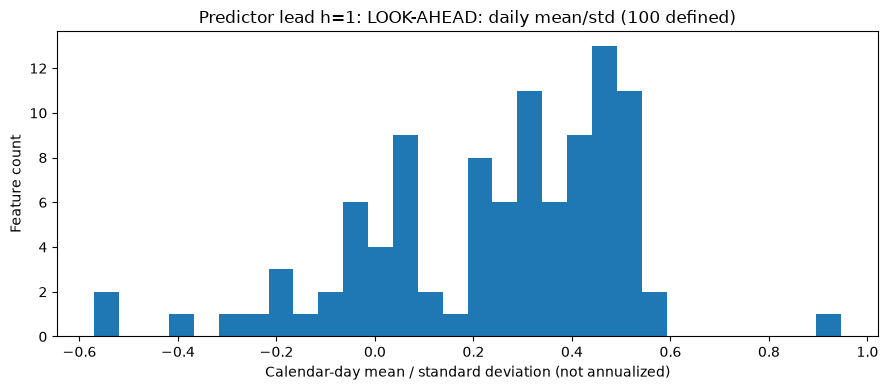

,daily_mean_over_std,pnl_observations,days_with_observations,first_pnl_msgStamp,last_pnl_msgStamp,max_abs_weight,capped_fraction
x100,0.945583,578331,2621,2014-02-03 10:50:00-05:00,2022-07-14 00:25:00-04:00,3.0,0.008758
x55,0.582514,472780,2580,2014-03-06 14:15:00-05:00,2022-07-14 00:25:00-04:00,3.0,0.018631
x7,0.547084,338801,1693,2017-02-05 22:00:00-05:00,2022-07-14 00:25:00-04:00,3.0,0.024088
x56,0.534155,472780,2580,2014-03-06 14:15:00-05:00,2022-07-14 00:25:00-04:00,3.0,0.018519
x1,0.530558,327821,2130,2014-02-26 12:05:00-05:00,2022-07-13 15:55:00-04:00,3.0,0.015655
x4,0.529848,323779,2111,2014-02-26 12:05:00-05:00,2022-07-13 15:55:00-04:00,3.0,0.014738
x49,0.519420,166707,2116,2014-04-22 10:45:00-04:00,2022-07-13 16:10:00-04:00,3.0,0.017023
x52,0.517758,161363,2114,2014-04-24 10:15:00-04:00,2022-07-13 15:50:00-04:00,3.0,0.017265
x37,0.505510,162775,2121,2014-04-23 15:40:00-04:00,2022-07-13 15:55:00-04:00,3.0,0.016114
x13,0.504086,146338,1372,2017-03-22 13:00:00-04:00,2022-07-13 15:55:00-04:00,3.0,0.016420


In [23]:
h = 1
oracle_returns = df.ret_5m.where(rows < len(df)-1)
blocks = (df[x_cols[start:start+8]].shift(-h) for start in range(0,len(x_cols),8))
oracle_daily, oracle_summary, oracle_meta = evaluate_features(
    blocks, oracle_returns, hl=HL, meta=True, meta_hl=META_HL, positive_only=True)
display_results(oracle_daily, f'Predictor lead h={h}: '+('control' if h==0 else 'LOOK-AHEAD'),
                meta_daily=oracle_meta.resample('D').sum())
if h==0:
    oracle_records, oracle_score_columns = [], {}
scores=oracle_summary.daily_mean_over_std
oracle_score_columns[h]=scores
oracle_records.append(dict(h=h, candidates=len(scores), defined=int(scores.notna().sum()),
    median_sharpe=scores.median(), p95_sharpe=scores.quantile(.95), best_sharpe=scores.max(),
    meta_sharpe=sharpe(oracle_meta.resample('D').sum()),
    median_pnl_observations=oracle_summary.pnl_observations.median()))
display(oracle_summary.head(10))


In [24]:
oracle_comparison=pd.DataFrame(oracle_records).set_index('h')
per_feature_oracle=pd.DataFrame(oracle_score_columns)
for h in [1]:
    delta=per_feature_oracle[h]-per_feature_oracle[0]
    oracle_comparison.loc[h,'median_sharpe_change_vs_h0']=delta.median()
    oracle_comparison.loc[h,'fraction_improved_vs_h0']=delta.gt(0).where(delta.notna()).mean()
display(oracle_comparison)
print('ORACLE_SHIFT_SUMMARY'); print(oracle_comparison.to_string())
assert df.index.max()<split['cutoff']


,candidates,defined,median_sharpe,p95_sharpe,best_sharpe,meta_sharpe,median_pnl_observations,median_sharpe_change_vs_h0,fraction_improved_vs_h0
h,,,,,,,,,
0,100,100,0.010576,0.057142,0.065944,0.039707,160014.0,NaN,NaN
1,100,100,0.304534,0.529883,0.945583,0.570885,160013.0,0.288235,0.81


ORACLE_SHIFT_SUMMARY
   candidates  defined  median_sharpe  p95_sharpe  best_sharpe  meta_sharpe  median_pnl_observations  median_sharpe_change_vs_h0  fraction_improved_vs_h0
h                                                                                                                                                        
0         100      100       0.010576    0.057142     0.065944     0.039707                 160014.0                         NaN                      NaN
1         100      100       0.304534    0.529883     0.945583     0.570885                 160013.0                    0.288235                     0.81


### Forecast each alpha one period ahead with Streaming Lasso

Fit one **AR(2)** model for each of x1 through x100. “Previous two predictors” means two time lags of that same alpha, not two unrelated columns. Once row t is observed, learn the relation from past examples and use the two currently available values:

$$x_s=a_t+b_{1,t}x_{s-1}+b_{2,t}x_{s-2}+e_s,\quad s\le t,$$
$$\widehat x_{t+1\mid t}=a_t+b_{1,t}x_t+b_{2,t}x_{t-1}.$$

Unlike the return-regression diagnostic, **x_t itself is already observed** at this decision. Updating the alpha model through x_t before forecasting x_{t+1} is causal; using x_{t+1} in fitting would not be. The forecast is stored at its **decision timestamp t**, ready to replace the deliberately look-ahead `x.shift(-1)` input. It is not shifted backward from a future fitted value. Tests alter future feature values and verify earlier forecasts are unchanged, and compare prefix fits with the direct CVXPY loss.

Use W=1 on finite target/lag triples, an intercept, half-life 6048, and at least 6048 complete examples before publishing a forecast. Missing lags are not zero-filled or backfilled. Missing examples advance the fitting decay clock. No return labels are used to fit these alpha forecasts, so their online update can continue during the price blackout, provided the alphas themselves remain available.

For comparable regularization across different alpha units, divide each alpha and its lags by a fixed standard deviation estimated from its **initial warm-up examples only**, excluding zero values. The scale is frozen thereafter; a constant warm-up uses an RMS/one fallback. Fit with the existing feature-scaled lasso penalty, then restore original units. The grid's alpha is therefore in initial-standard-deviation units, not directly comparable with the return-regression alpha. Earlier warm-up fits are never scored. Hyperparameters are fixed candidates, not chosen using the reserved test period.

Backtest each forecast using the shared lagged, floored and capped signal-only position multiplied by `ret_5m`, with the new zero/missing volatility convention. A persistence control uses x_t on the same causal availability mask. The oracle control uses the actual x_{t+1}, explicitly noncausal. The realized next alpha is used **only to evaluate forecast error**, never to construct the forecast or to filter the causal P&L. The existing ret_5m alignment is retained; a deployable trading claim still requires confirming that its return interval starts after the decision.


#### AR(2) regularization sweep

Present candidate performance as plots, not tables. Every candidate fits all 100 alpha series and all their training observations. The fixed illustrative penalty is 0.01; it is not replaced by the best point after viewing the charts. For this comparison, forecast, persistence and oracle combinations all use **signed** lagged EWM-Sharpe weights, so allocation constraints do not confound the comparison. The earlier raw-family plot retains its original nonnegative scores.


/home/runner/work/th/th/src/takehome/fitters.py:747: RuntimeWarning: 1 updates did not converge; inspect KKT errors or raise max_iter.
  model.fit(lags/scale, values/scale, W=valid.astype(float))


/home/runner/work/th/th/src/takehome/fitters.py:747: RuntimeWarning: 1 updates did not converge; inspect KKT errors or raise max_iter.
  model.fit(lags/scale, values/scale, W=valid.astype(float))


AR(2) alpha=0.001: 100 signals; 2 nonconverged updates; 333.7s


AR(2) alpha=0.01: 100 signals; 0 nonconverged updates; 148.5s


AR(2) alpha=0.1: 100 signals; 0 nonconverged updates; 23.2s


AR(2) alpha=1: 100 signals; 0 nonconverged updates; 22.6s


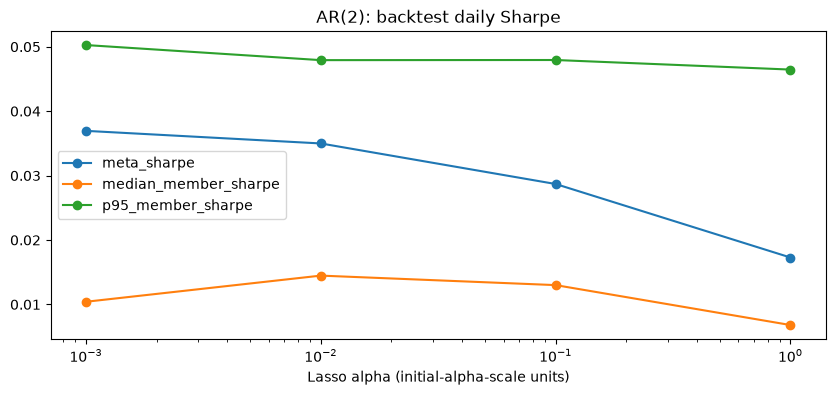

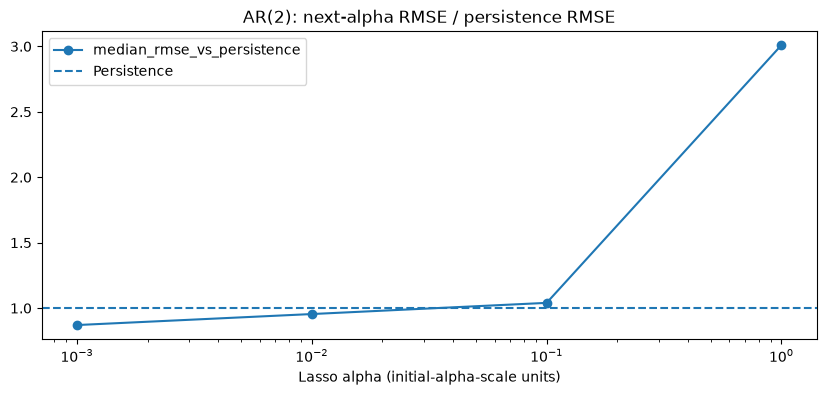

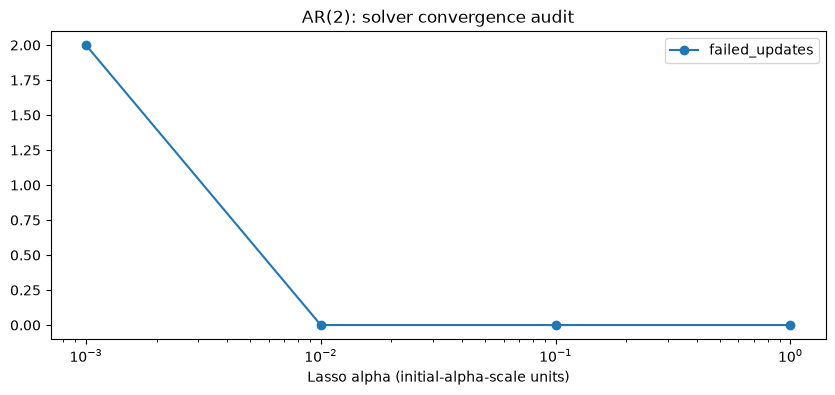

alpha=0.001: meta daily Sharpe=0.036944; median member Sharpe=0.010412; median RMSE/persistence=0.870578; failed updates=2
alpha=0.01: meta daily Sharpe=0.034988; median member Sharpe=0.014472; median RMSE/persistence=0.954649; failed updates=0
alpha=0.1: meta daily Sharpe=0.028692; median member Sharpe=0.012997; median RMSE/persistence=1.040090; failed updates=0
alpha=1: meta daily Sharpe=0.017281; median member Sharpe=0.006797; median RMSE/persistence=3.010080; failed updates=0


In [25]:
from takehome.fitters import forecast_alpha_blocks

AR_ALPHAS = [1e-3,1e-2,1e-1,1.]
AR_DEFAULT, AR_MIN_TRAIN = .01, HL
alpha_returns = df.ret_5m.where(rows < len(df)-1)
ar_records, ar_diagnostics, ar_meta_paths = [], {}, {}

def measured_alpha_blocks(penalty, diagnostics):
    for block in forecast_alpha_blocks(df[x_cols],hl=HL,alpha=penalty,
                                      min_train=AR_MIN_TRAIN,batch_size=8,diagnostics=diagnostics):
        for j,col in enumerate(block):
            current=df[col]
            actual=current.shift(-1)  # Evaluation only. Not supplied to the fitter.
            valid=np.isfinite(block[col]) & np.isfinite(current) & np.isfinite(actual)
            error=(block.loc[valid,col]-actual[valid]).pow(2).mean()
            persistence_error=(current[valid]-actual[valid]).pow(2).mean()
            diagnostics[-len(block.columns)+j].update(
                forecast_pairs=int(valid.sum()),
                rmse_vs_persistence=np.sqrt(error/persistence_error) if persistence_error>0 else np.nan)
        yield block

for penalty in AR_ALPHAS:
    info=[]; started=perf_counter()
    days,summary,meta=evaluate_features(measured_alpha_blocks(penalty,info),alpha_returns,
                                      hl=HL,meta=True,meta_hl=META_HL,positive_only=False)
    fit_info=pd.DataFrame(info).set_index('feature')
    ratio=fit_info.rmse_vs_persistence
    scores=summary.daily_mean_over_std
    ar_records.append(dict(alpha=penalty,meta_sharpe=sharpe(meta.resample('D').sum()),
        median_member_sharpe=scores.median(),p95_member_sharpe=scores.quantile(.95),
        median_rmse_vs_persistence=ratio.median(),fraction_rmse_improved=ratio.dropna().lt(1).mean(),
        failed_updates=int(fit_info.failed_updates.sum()),seconds=perf_counter()-started))
    ar_diagnostics[penalty]=fit_info
    ar_meta_paths[penalty]=meta
    if penalty==AR_DEFAULT:
        ar_default_daily,ar_default_summary,ar_default_meta=days,summary,meta
    print(f'AR(2) alpha={penalty:g}: {len(info)} signals; {ar_records[-1]["failed_updates"]} nonconverged updates; {ar_records[-1]["seconds"]:.1f}s')
ar_sweep=pd.DataFrame(ar_records).set_index('alpha')
for metrics,title in [(['meta_sharpe','median_member_sharpe','p95_member_sharpe'],'AR(2): backtest daily Sharpe'),
                      (['median_rmse_vs_persistence'],'AR(2): next-alpha RMSE / persistence RMSE'),
                      (['failed_updates'],'AR(2): solver convergence audit')]:
    ax=ar_sweep[metrics].plot(logx=True,marker='o',figsize=(10,4),title=title)
    if 'median_rmse_vs_persistence' in metrics:
        ax.axhline(1,linestyle='--',label='Persistence'); ax.legend()
    ax.set_xlabel('Lasso alpha (initial-alpha-scale units)'); plt.show(); plt.close('all')

for penalty, row in ar_sweep.iterrows():
    print(f'alpha={penalty:g}: meta daily Sharpe={row.meta_sharpe:.6f}; median member Sharpe={row.median_member_sharpe:.6f}; median RMSE/persistence={row.median_rmse_vs_persistence:.6f}; failed updates={int(row.failed_updates)}')


#### Backtest the fixed AR(2) forecasts

All lines use the alpha forecast made at that decision timestamp. The purple secondary-axis line combines those forecasts' individual backtests using only earlier P&Ls. Histogram entries are individual alpha strategies, not model-fitting correlations.


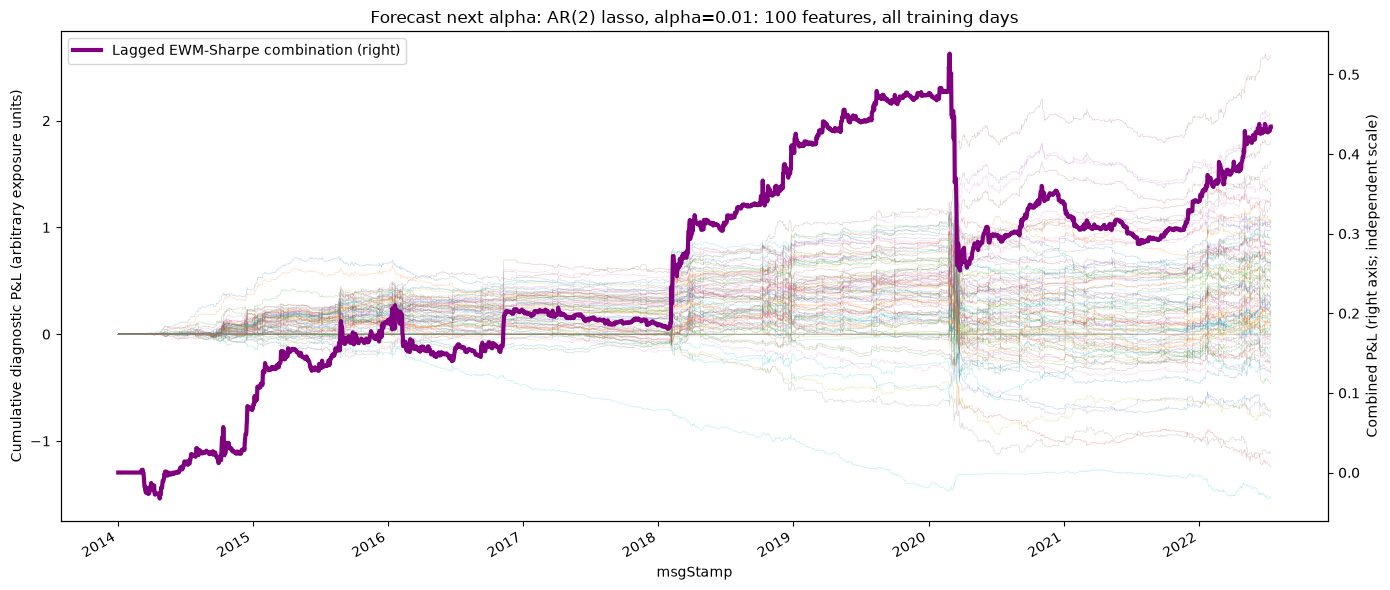

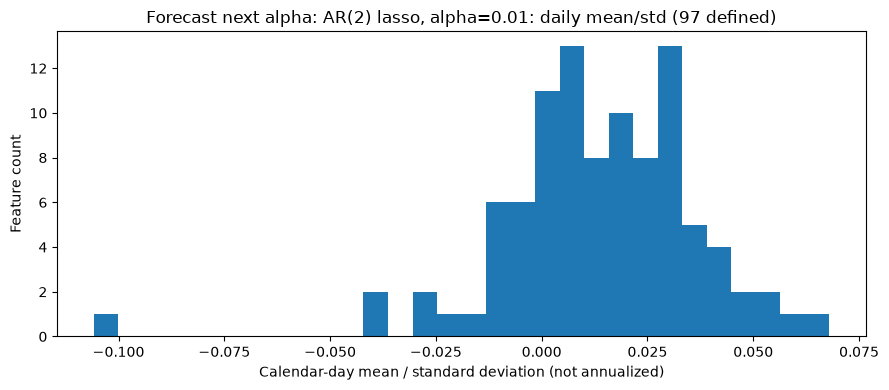

x1      0.022294
x2      0.032660
x3      0.029848
x4     -0.009023
x5      0.005287
          ...   
x96     0.028851
x97     0.039291
x98     0.024127
x99     0.023164
x100   -0.105808
Length: 100, dtype: float64

In [26]:
display_results(ar_default_daily,f'Forecast next alpha: AR(2) lasso, alpha={AR_DEFAULT:g}',
                meta_daily=ar_default_meta.resample('D').sum())


#### Matched persistence and realized-future controls

The persistence input is the current alpha, which is the forecast x_{t+1}=x_t. It uses exactly the same **causal** warm-up and current-lag availability rule as AR(2). The oracle uses the actual next value; it may additionally be missing when that future value is unavailable. No future-availability condition is imposed on the AR(2) or persistence backtests. The final training target row is omitted from all three. Volatility warm-ups can still differ when a forecast is exactly zero, so coverage is reported by the underlying summaries.


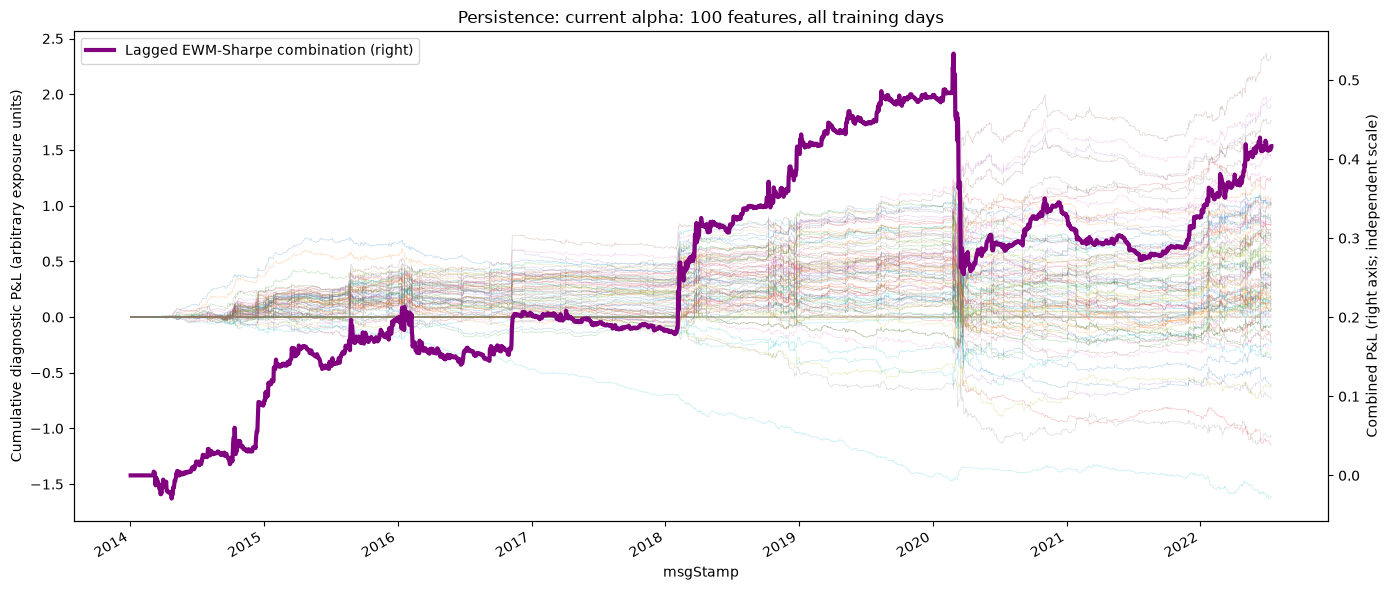

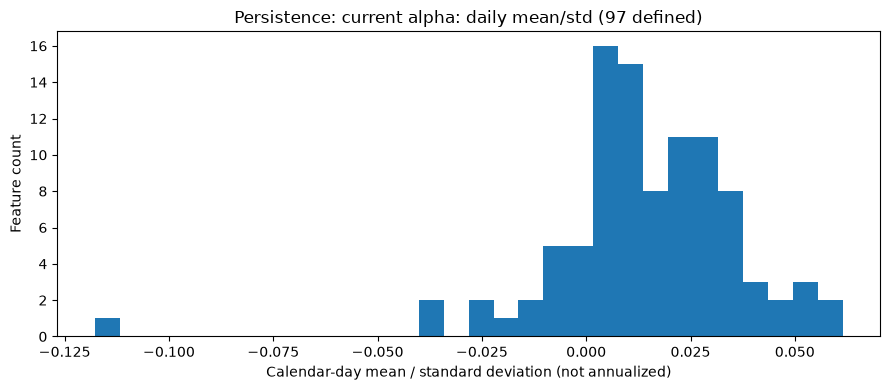

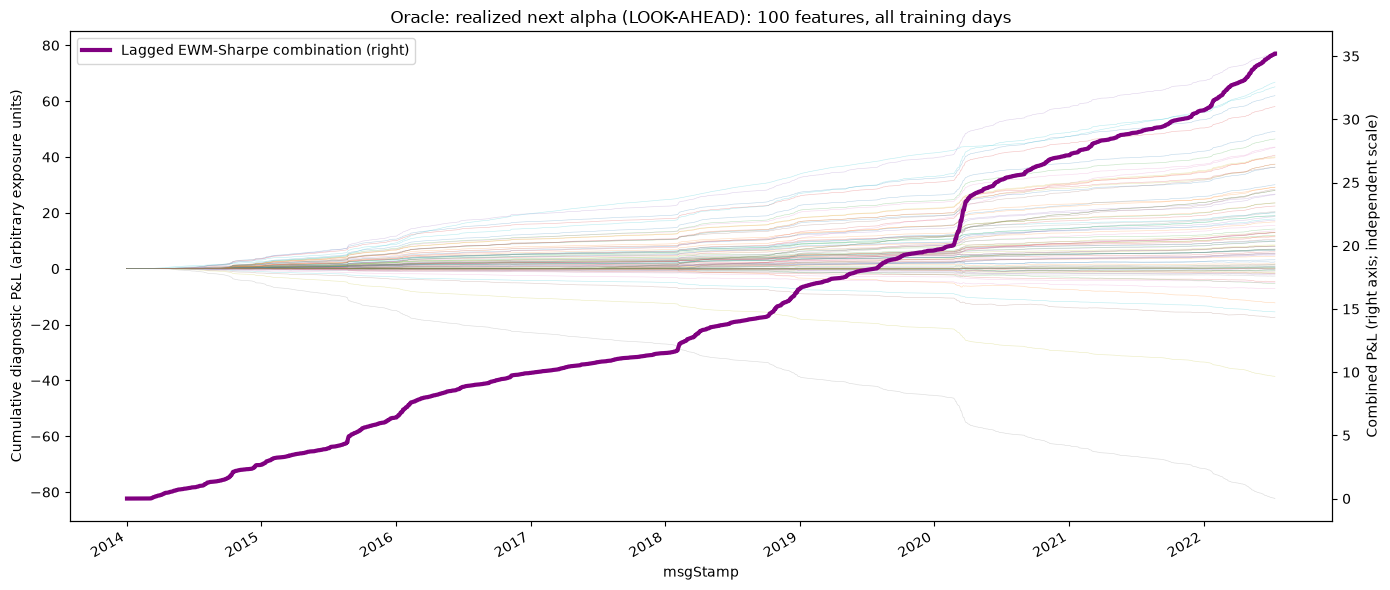

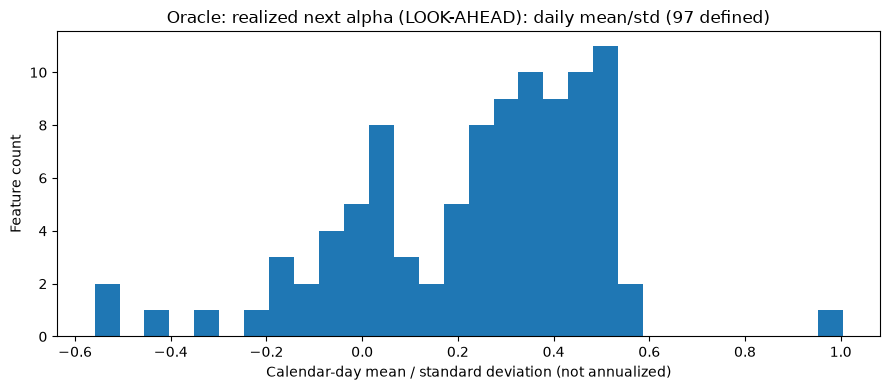

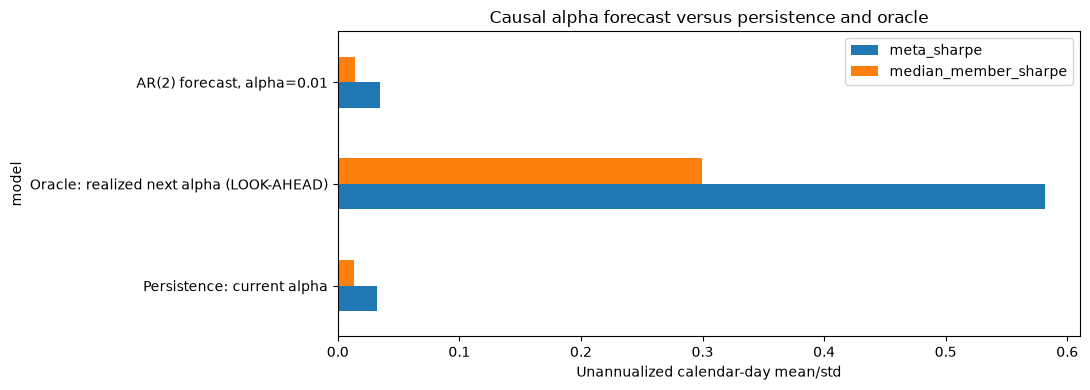

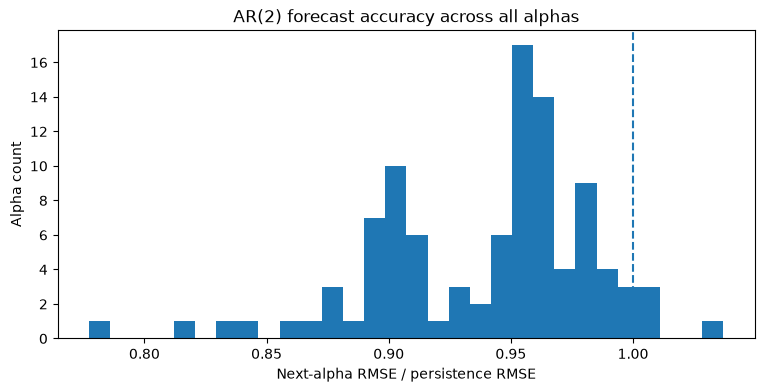

Default AR(2): 96/100 alphas beat persistence on forecast RMSE; median ratio=0.9546.
Persistence: current alpha: meta daily Sharpe=0.032638; median member Sharpe=0.013550; median PnL observations=151221
Oracle: realized next alpha (LOOK-AHEAD): meta daily Sharpe=0.581418; median member Sharpe=0.299450; median PnL observations=148719
AR(2) forecast, alpha=0.01: meta daily Sharpe=0.034988; median member Sharpe=0.014472; median PnL observations=151221


In [27]:
def matched_alpha_controls(oracle=False):
    for start in range(0,len(x_cols),8):
        X=df[x_cols[start:start+8]].replace([np.inf,-np.inf],np.nan)
        triples=X.notna() & X.shift(1).notna() & X.shift(2).notna()
        ready=triples.cumsum().ge(AR_MIN_TRAIN) & X.notna() & X.shift(1).notna()
        yield (X.shift(-1) if oracle else X).where(ready)

control_records=[]
for oracle,label in [(False,'Persistence: current alpha'),(True,'Oracle: realized next alpha (LOOK-AHEAD)')]:
    days,summary,meta=evaluate_features(matched_alpha_controls(oracle),alpha_returns,
                                      hl=HL,meta=True,meta_hl=META_HL,positive_only=False)
    display_results(days,label,meta_daily=meta.resample('D').sum())
    control_records.append(dict(model=label,meta_sharpe=sharpe(meta.resample('D').sum()),
        median_member_sharpe=summary.daily_mean_over_std.median(),
        median_pnl_observations=summary.pnl_observations.median()))
control_records.append(dict(model='AR(2) forecast, alpha=0.01',meta_sharpe=sharpe(ar_default_meta.resample('D').sum()),
    median_member_sharpe=ar_default_summary.daily_mean_over_std.median(),
    median_pnl_observations=ar_default_summary.pnl_observations.median()))
ar_comparison=pd.DataFrame(control_records).set_index('model')
ar_comparison[['meta_sharpe','median_member_sharpe']].plot.barh(figsize=(11,4),title='Causal alpha forecast versus persistence and oracle')
plt.xlabel('Unannualized calendar-day mean/std'); plt.tight_layout(); plt.show(); plt.close('all')
ratios=ar_diagnostics[AR_DEFAULT].rmse_vs_persistence.dropna()
plt.figure(figsize=(9,4)); plt.hist(ratios,bins=30)
plt.axvline(1,linestyle='--'); plt.xlabel('Next-alpha RMSE / persistence RMSE')
plt.ylabel('Alpha count'); plt.title('AR(2) forecast accuracy across all alphas'); plt.show(); plt.close('all')
print(f'Default AR(2): {ratios.lt(1).sum()}/{len(ratios)} alphas beat persistence on forecast RMSE; median ratio={ratios.median():.4f}.')
assert df.index.max()<split['cutoff']

for name, row in ar_comparison.iterrows():
    print(f'{name}: meta daily Sharpe={row.meta_sharpe:.6f}; median member Sharpe={row.median_member_sharpe:.6f}; median PnL observations={row.median_pnl_observations:g}')


## Walk-forward regression backtests

Use all **100 dszl(10) predictors**, including transformed x100=cashflow/volume. Missing/nonfinite transformed inputs are zero-imputed only in the model matrix; no target is filled. All models receive this same matrix, with unit observation weights on finite research labels and the same two-year windows. The raw-return predictions are never standardized or clipped for calibration or export; only their diagnostic positions use `SIGNAL_RULE`.

<span style="color:red">TODO — Fitting: assess weighting by volume, because feasible size to be traded may be proxied by market volume. Define the decision-time volume/availability convention and compare capacity, turnover and costs. The current submitted configuration remains explicitly unit-weighted; no volume-weighted result is claimed.</span>

## Objective and shared interface

With $a_{i,t}=W_i d^{t-i}$, $A=\sum a_i$ and weighted population feature scales $s_j$, the lasso loss is
$$\frac{1}{2A}\sum_i a_i(y_i-b-x_i^\top\beta)^2+\alpha\sum_j s_j|\beta_j|.$$
Ridge replaces the last term by $\alpha\sum_j(s_j\beta_j)^2/2$. Both leave the intercept unpenalized. All scales/means are fitted inside the previous training window.

`StreamingWeightedLasso_` is a real Numba jitclass owning state and compiled methods. `StreamingWeightedLasso` validates inputs, warns on nonconvergence, and exposes the familiar history and prediction interface. Welford/coordinate-descent mathematics is unchanged; forecasts are emitted directly in the compiled row loop before incorporating that row's label.

`BatchLasso` solves an independent CVXPY quadratic program from batch-recomputed moments. `CvxpyWeightedLasso` retains the original-row residual loss as a separate reference. `BatchRidge` solves the normal equations. `walk_forward_sweep` shares batch moments across penalties, not fitted parameters across evaluation rows. `BatchedFitters.get_coefs(lag=1)` and `get_intercepts(lag=1)` reconstruct its OOS `prediction_`.

## Fold and hyperparameter contract

Use a **rolling two-calendar-year training window**, then hold coefficients fixed over the **next two calendar years**, and advance by two years. `calendar_walk_forward_folds` uses timestamps and `DateOffset(years=2)`, not a fixed bars-per-year approximation. The final forecast window is clipped to the available research data. The fold table retains both exact nominal calendar boundaries and actual row bounds.

Both batch models and the frozen streaming comparison use only that fold's preceding two years, with the existing decay $d=2^{-1/6048}$ inside the window. The continuous `live` streaming series remains an explicitly separate online EWM baseline; it is not a frozen walk-forward fit. The current prediction row's target is excluded. The prior row's label is assumed available, as in the existing beta.shift convention; add an embargo if target maturity requires it.

Every sweep point is scored on forecasts from a previous fold, not fitted values. Grid values are fixed in advance; no best-alpha selection is claimed to be unbiased after viewing these validation scores. These are **walk-forward validation results inside the training 80%**, not results on the reserved test block. The first 6,048 nonzero OOS forecasts warm the lagged signal-scale estimator; all models use the same subsequent evaluation span.

In [28]:
from takehome.fitters import (StreamingWeightedLasso, BatchRidge, BatchLasso,
                              CvxpyWeightedLasso, BatchedFitters, walk_forward_sweep,
                              calendar_walk_forward_folds, stream_at_folds, batch_moments, _scaled_moments)
from takehome.features import backtest, forecast_metrics
from takehome.plots import plot_calibration
from time import perf_counter

fit_columns = list(x_cols)
assert len(fit_columns) == 100 and fit_columns[-1] == 'x100'
model_X = dszl_design(df[fit_columns], hl=DSZL_HL, batch_size=BATCH_SIZE)
X_fit = model_X.to_numpy(copy=False)
assert X_fit.flags.c_contiguous and np.isfinite(X_fit).all()
y_fit = df.ret_5m.to_numpy(dtype=float)
valid_fit = np.isfinite(y_fit)
W_fit = valid_fit.astype(float)
DECAY, DEFAULT_ALPHA, RIDGE_ALPHA = RIDGE_CONFIG['decay'], 1e-5, RIDGE_CONFIG['alpha']
LASSO_ALPHAS = np.array([1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4])
RIDGE_ALPHAS = np.logspace(-6, 2, 9)
folds = calendar_walk_forward_folds(df.index, train_years=WINDOW_YEARS, test_years=WINDOW_YEARS)
FOLD = dict(folds=folds)
OOS_FIRST = folds[0]['predict_start']
SCORE_FIRST = OOS_FIRST + HL
rows = np.arange(len(df))
score_day = df.index[SCORE_FIRST].normalize()

def oos_series(values):
    return pd.Series(values, index=df.index).where(rows >= OOS_FIRST)

def score_prediction(prediction):
    per_bar = backtest(prediction, df.ret_5m, HL, normalization=SIGNAL_RULE).where(rows >= SCORE_FIRST)
    daily = per_bar.resample('D').sum().loc[score_day:]
    stats = forecast_metrics(prediction.iloc[SCORE_FIRST:], df.ret_5m.iloc[SCORE_FIRST:])
    return daily, dict(daily_sharpe=sharpe(daily), pnl_observations=int(per_bar.count()),
                       max_abs_weight=signal_weights(prediction, HL, **SIGNAL_RULE).abs().max(), **stats)

fold_table = pd.DataFrame(folds)
for key in ['train_start','train_stop','predict_start','predict_stop']:
    fold_table[key+'_msgStamp'] = [df.index[min(int(v),len(df)-1)] for v in fold_table[key]]
display(fold_table.head(8))
print(f'WF_PROTOCOL: rolling 2-calendar-year train / 2-calendar-year forecast; {len(folds)} folds; {len(df)} training rows; {len(fit_columns)} predictors')
print('First OOS forecast:', df.index[OOS_FIRST], '; first scoring row:', df.index[SCORE_FIRST])
print('Valid target rows:', int(W_fit.sum()), '; x100 finite rows:', int(df.x100.notna().sum()))


,train_start,train_stop,predict_start,predict_stop,train_start_time,train_stop_time,predict_start_time,predict_stop_time,train_start_msgStamp,train_stop_msgStamp,predict_start_msgStamp,predict_stop_msgStamp
0,0,150191,150191,300384,2014-01-02 06:05:00-05:00,2016-01-02 06:05:00-05:00,2016-01-02 06:05:00-05:00,2018-01-02 06:05:00-05:00,2014-01-02 06:05:00-05:00,2016-01-03 18:00:00-05:00,2016-01-03 18:00:00-05:00,2018-01-02 06:05:00-05:00
1,150191,300384,300384,450720,2016-01-02 06:05:00-05:00,2018-01-02 06:05:00-05:00,2018-01-02 06:05:00-05:00,2020-01-02 06:05:00-05:00,2016-01-03 18:00:00-05:00,2018-01-02 06:05:00-05:00,2018-01-02 06:05:00-05:00,2020-01-02 06:05:00-05:00
2,300384,450720,450720,600911,2018-01-02 06:05:00-05:00,2020-01-02 06:05:00-05:00,2020-01-02 06:05:00-05:00,2022-01-02 06:05:00-05:00,2018-01-02 06:05:00-05:00,2020-01-02 06:05:00-05:00,2020-01-02 06:05:00-05:00,2022-01-02 18:00:00-05:00
3,450720,600911,600911,640734,2020-01-02 06:05:00-05:00,2022-01-02 06:05:00-05:00,2022-01-02 06:05:00-05:00,2024-01-02 06:05:00-05:00,2020-01-02 06:05:00-05:00,2022-01-02 18:00:00-05:00,2022-01-02 18:00:00-05:00,2022-07-14 00:30:00-04:00


WF_PROTOCOL: rolling 2-calendar-year train / 2-calendar-year forecast; 4 folds; 640734 training rows; 100 predictors
First OOS forecast: 2016-01-03 18:00:00-05:00 ; first scoring row: 2016-02-01 18:00:00-05:00
Valid target rows: 590635 ; x100 finite rows: 592734


## Numerical reference: direct CVXPY residual loss

This synthetic check uses exactly matched prefix observations, decay, feature-scaled penalty and intercept convention. The later real-data checks separately compare two-year-window batch moments and frozen forecasts.

In [29]:
# Independent CVXPY loss at identical prefixes; no Numba Gram/CD reuse.
from takehome.fitters import StreamingWeightedLasso, CvxpyWeightedLasso, BatchedFitters

rng = np.random.default_rng(42)
X_check = rng.normal(size=(256, 4)) * [1, 2, 3, 4] + .3
y_check = .2 + X_check @ np.array([.6, 0, -.3, .15]) + rng.normal(size=256) * .1
v_check = (rng.uniform(1800, 2200, 256) * rng.lognormal(4, 1, 256))**2
decay, alpha = .99, .05
verification = []
for with_intercept in [False, True]:
    online = StreamingWeightedLasso(4, decay, alpha, max_iter=50000, tol=1e-11,
                                    fit_intercept=with_intercept, store_history=True).fit(X_check, y_check, W=v_check)
    for n in [32, 64, 128, 256]:
        ref = CvxpyWeightedLasso(4, decay, alpha, fit_intercept=with_intercept, tol=1e-12)
        ref.fit(X_check[:n], y_check[:n], W=v_check[:n])
        beta, bias = online.get_coefs()[n-1], online.get_intercepts()[n-1]
        a = v_check[:n] * decay**np.arange(n-1, -1, -1); a /= a.sum()
        loss_online = .5 * (a @ (y_check[:n] - X_check[:n] @ beta - bias)**2)
        loss_online += alpha * np.sum(ref.scale_ * np.abs(beta))
        verification.append({
            'intercept': with_intercept, 'prefix_rows': n,
            'max_coefficient_error': np.max(np.abs(beta-ref.coef)),
            'max_prediction_error': np.max(np.abs(X_check[:n] @ beta+bias-ref.predict(X_check[:n]))),
            'objective_gap': abs(loss_online-ref.objective_), 'cvxpy_status': ref.status_,
        })
    assert online.n_failed_ == 0
verification = pd.DataFrame(verification)
with pd.option_context('display.float_format', '{:.3e}'.format):
    display(verification)
print('CVXPY_RECONCILIATION'); print(verification.to_string(index=False))
assert verification.max_coefficient_error.max() < 5e-7
assert verification.max_prediction_error.max() < 2e-6
assert verification.objective_gap.max() < 1e-9

,intercept,prefix_rows,max_coefficient_error,max_prediction_error,objective_gap,cvxpy_status
0,False,32,9.180e-12,1.798e-11,9.798e-15,optimal
1,False,64,2.430e-12,1.106e-11,1.870e-13,optimal
2,False,128,7.286e-11,2.514e-10,1.388e-17,optimal
3,False,256,1.121e-11,6.500e-11,3.873e-14,optimal
4,True,32,3.299e-11,6.444e-11,1.388e-17,optimal
5,True,64,1.580e-11,5.286e-11,4.577e-14,optimal
6,True,128,3.774e-11,1.281e-10,7.340e-14,optimal
7,True,256,1.708e-11,7.006e-11,1.601e-13,optimal


CVXPY_RECONCILIATION
 intercept  prefix_rows  max_coefficient_error  max_prediction_error  objective_gap cvxpy_status
     False           32           9.179768e-12          1.797673e-11   9.797718e-15      optimal
     False           64           2.429501e-12          1.106049e-11   1.870171e-13      optimal
     False          128           7.286183e-11          2.513921e-10   1.387779e-17      optimal
     False          256           1.121292e-11          6.499645e-11   3.873291e-14      optimal
      True           32           3.299450e-11          6.443518e-11   1.387779e-17      optimal
      True           64           1.579625e-11          5.286119e-11   4.576894e-14      optimal
      True          128           3.774026e-11          1.281258e-10   7.339962e-14      optimal
      True          256           1.708045e-11          7.005918e-11   1.600664e-13      optimal


## Batch Ridge and batch lasso: next-fold OOS sweeps

One batch moment calculation per cutoff and decay is reused across the penalty grid. No future rows enter that calculation. Each fitted model is frozen over its next prediction fold; a rolling-window fit is never applied backward to its own training rows.

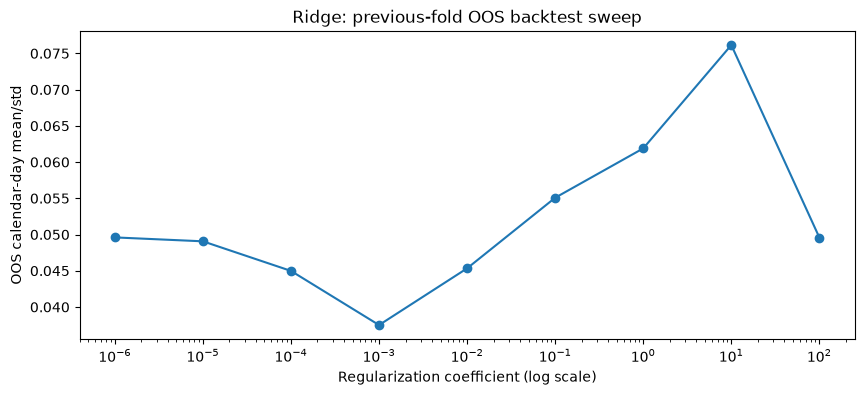

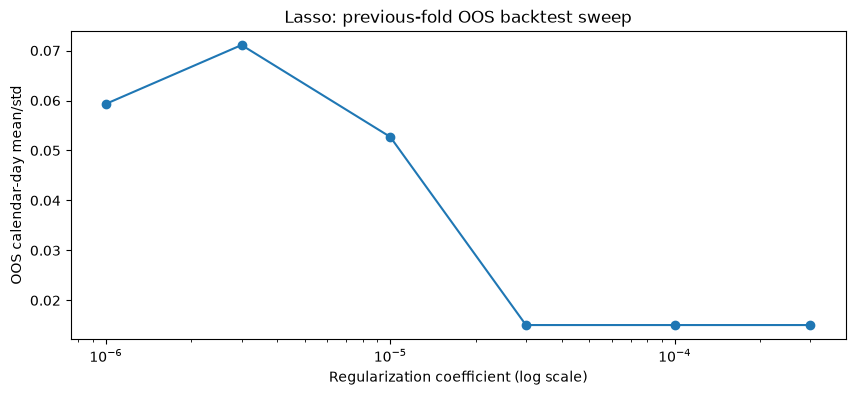

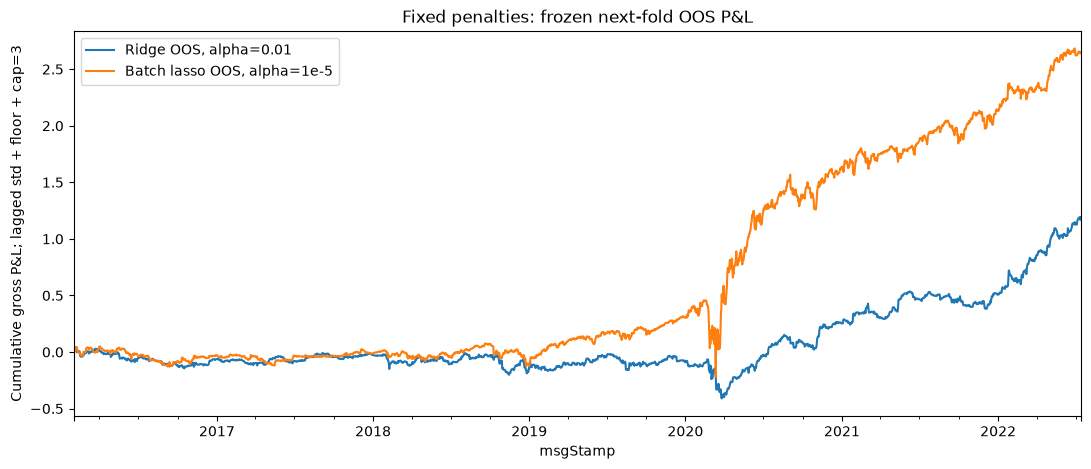

Batch grid: 15 fixed candidates, 4 chronological folds; 1.5 seconds.


In [30]:
models = {f'Ridge {a:g}': BatchRidge(len(fit_columns), **(RIDGE_CONFIG | {'alpha': float(a)})) for a in RIDGE_ALPHAS}
models.update({f'Lasso {a:g}': BatchLasso(len(fit_columns), DECAY, float(a),
                                      fit_intercept=True, tol=1e-11) for a in LASSO_ALPHAS})
started = perf_counter()
batch_paths = walk_forward_sweep(models, X_fit, y_fit, W=W_fit, **FOLD)
batch_seconds = perf_counter()-started
batch_daily, batch_rows = {}, []
for name, path in batch_paths.items():
    daily, stats = score_prediction(oos_series(path.prediction_))
    batch_daily[name] = daily
    batch_rows.append(dict(model=name.split()[0], alpha=models[name].alpha, **stats))
batch_sweep = pd.DataFrame(batch_rows).set_index(['model','alpha'])
for family in ['Ridge', 'Lasso']:
    batch_sweep.loc[family, 'daily_sharpe'].plot(logx=True, marker='o', figsize=(10,4),
        title=f'{family}: previous-fold OOS backtest sweep')
    plt.xlabel('Regularization coefficient (log scale)'); plt.ylabel('OOS calendar-day mean/std')
    plt.show(); plt.close('all')
fixed_batch = pd.DataFrame({
    'Ridge OOS, alpha=0.01': batch_daily[f'Ridge {RIDGE_ALPHA:g}'],
    'Batch lasso OOS, alpha=1e-5': batch_daily[f'Lasso {DEFAULT_ALPHA:g}'],
})
fixed_batch.cumsum().plot(figsize=(13,5),title='Fixed penalties: frozen next-fold OOS P&L')
plt.ylabel('Cumulative gross P&L; lagged std + floor + cap=3'); plt.show(); plt.close('all')

print(f'Batch grid: {len(models)} fixed candidates, {len(folds)} chronological folds; {batch_seconds:.1f} seconds.')

assert batch_sweep.max_abs_weight.max() <= SIGNAL_RULE['cap']


### Why can Ridge backtests be very large?

Ridge shrinkage makes return forecasts small. The legacy $\hat y/\sigma_{\hat y}^2$ then **increases** exposure as forecast amplitude shrinks. A nearly constant nonzero intercept can also coexist with a tiny centered standard deviation. Changing the walk-forward window does not, by itself, bound that division.

The old normalization notebook's Original shape curve multiplies legacy exposure by the first observed scale. This removes units dependence, **not** concentration in a few bars. The audit below reconstructs both controls on the **same dszl Ridge forecasts and matched rows**, then compares the selected lagged std/floor/cap rule. Large-return days remain visible; no return or P&L is clipped.

<span style="color:red">TODO — Ridge sizing: investigate an uncertainty-aware t-stat score instead of yhat/ewm_std(yhat). A forecast t-stat would divide by an estimated forecast standard error, not by the temporal volatility of forecasts; define a valid uncertainty estimate for regularization and serial dependence before implementing it. The current stabilizer is the explicit floor/cap, not a claimed t-stat implementation.</span>


,observations,max_abs_weight,p99_abs_weight,max_abs_bar_pnl,max_abs_day_pnl,max_abs_day_over_daily_std,top10_abs_pnl_share,daily_mean_over_std,capped_percent
rule,,,,,,,,,
Legacy raw units,446236,562072.523267,149511.152507,2607.489235,4388.353336,10.153105,0.408759,0.036708,0.000000
Original shape,446236,29.426460,7.827431,0.136511,0.229746,10.153105,0.408759,0.036708,0.000000
Prior variance,446236,29.735754,7.838676,0.137048,0.230823,10.179826,0.410363,0.036684,0.000000
Floored variance + cap,446236,3.000000,3.000000,0.068923,0.119142,8.590458,0.283942,0.049193,8.498642
Std + floor + cap,446236,3.000000,3.000000,0.059682,0.116651,10.471400,0.372805,0.045334,2.594591
RMS + floor + cap,446236,3.000000,3.000000,0.059682,0.115648,10.433614,0.373665,0.045453,2.546859


DEFAULT_RIDGE_SIZING
                        observations  max_abs_weight  p99_abs_weight  max_abs_bar_pnl  max_abs_day_pnl  max_abs_day_over_daily_std  top10_abs_pnl_share  daily_mean_over_std  capped_percent
rule                                                                                                                                                                                        
Legacy raw units              446236   562072.523267   149511.152507      2607.489235      4388.353336                   10.153105             0.408759             0.036708        0.000000
Original shape                446236       29.426460        7.827431         0.136511         0.229746                   10.153105             0.408759             0.036708        0.000000
Prior variance                446236       29.735754        7.838676         0.137048         0.230823                   10.179826             0.410363             0.036684        0.000000
Floored variance + cap        4462

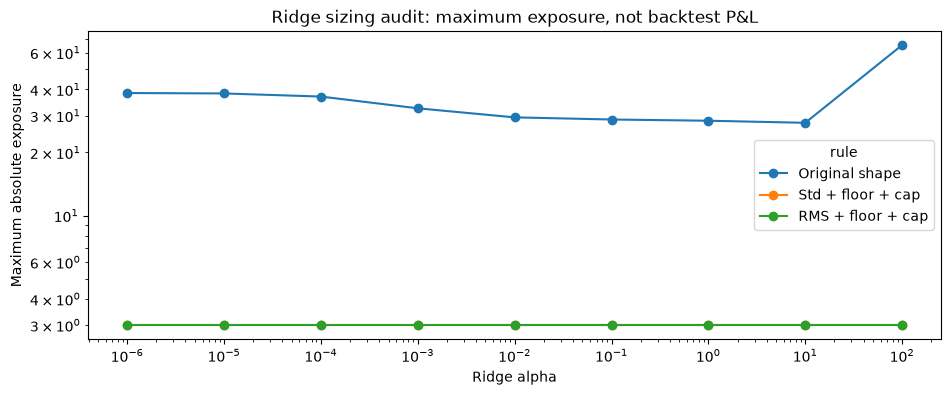

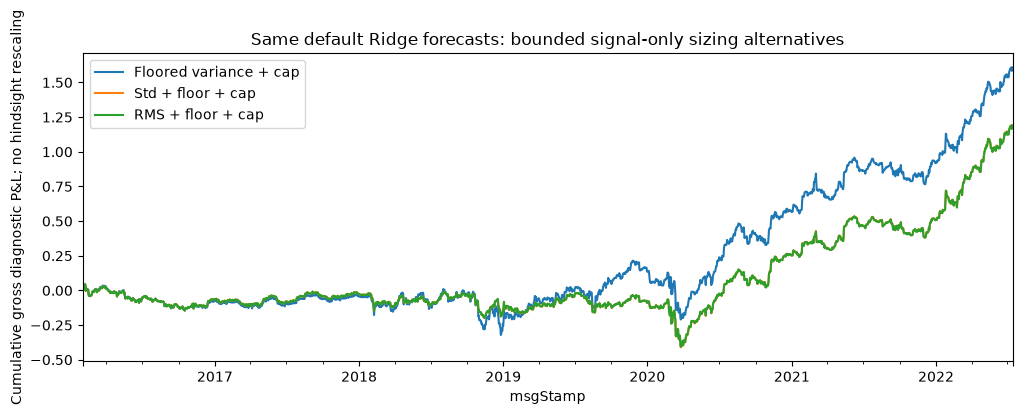

Only an explicit exposure bound guarantees control against arbitrary new signal outliers.


In [31]:
SIZING_RULES = {
    'Legacy raw units': None,
    'Original shape': dict(method='variance', floor_fraction=0, cap=None, lag=0),
    'Prior variance': dict(method='variance', floor_fraction=0, cap=None, lag=1),
    'Floored variance + cap': dict(method='variance', floor_fraction=.25, cap=3., lag=1),
    'Std + floor + cap': SIGNAL_RULE,
    'RMS + floor + cap': dict(method='rms', floor_fraction=.25, cap=3., lag=1),
}

def compare_sizing(prediction, returns, first_row):
    positions = pd.DataFrame({name: (prediction.div(ts_std(prediction, HL).pow(2))
        if rule is None else signal_weights(prediction, HL, **rule))
        for name, rule in SIZING_RULES.items()})
    common = positions.notna().all(axis=1) & np.isfinite(returns) & (np.arange(len(returns)) >= first_row)
    positions = positions.where(common, axis=0)
    contributions = positions.mul(returns, axis=0)
    daily = contributions.resample('D').sum().loc[returns.index[first_row].normalize():]
    records = []
    for name in positions:
        w = positions[name].dropna().abs(); p = contributions[name].dropna()
        total = p.abs().sum(); sigma = daily[name].std()
        records.append(dict(rule=name, observations=len(w), max_abs_weight=w.max(),
            p99_abs_weight=w.quantile(.99), max_abs_bar_pnl=p.abs().max(),
            max_abs_day_pnl=daily[name].abs().max(),
            max_abs_day_over_daily_std=daily[name].abs().max()/sigma if sigma > 0 else np.nan,
            top10_abs_pnl_share=100*p.abs().nlargest(10).sum()/total if total > 0 else np.nan,
            daily_mean_over_std=sharpe(daily[name]),
            capped_percent=100*w.ge(3.-1e-12).mean() if SIZING_RULES[name] is not None and SIZING_RULES[name].get('cap') is not None else 0.))
    return pd.DataFrame(records).set_index('rule'), positions, contributions, daily

sizing_tables, selected_sizing_daily = [], None
for a in RIDGE_ALPHAS:
    prediction = oos_series(batch_paths[f'Ridge {a:g}'].prediction_)
    stats, positions, contributions, daily = compare_sizing(prediction, df.ret_5m, SCORE_FIRST)
    sizing_tables.append(stats.assign(alpha=a))
    for name, rule in SIZING_RULES.items():
        if rule is not None and rule.get('cap') is not None:
            assert positions[name].abs().max() <= rule['cap']
            assert ((contributions[name].abs() <= rule['cap'] * df.ret_5m.abs()) | contributions[name].isna()).all()
    if a == RIDGE_ALPHA:
        ridge_sizing = stats
        selected_sizing_daily = daily
        display(stats)
        print('DEFAULT_RIDGE_SIZING'); print(stats.to_string())
all_ridge_sizing = pd.concat(sizing_tables).reset_index().set_index(['alpha','rule'])
all_ridge_sizing.max_abs_weight.unstack('rule')[['Original shape','Std + floor + cap','RMS + floor + cap']].plot(
    logx=True, logy=True, marker='o', figsize=(11,4), title='Ridge sizing audit: maximum exposure, not backtest P&L')
plt.xlabel('Ridge alpha'); plt.ylabel('Maximum absolute exposure'); plt.show(); plt.close('all')
selected_sizing_daily[['Floored variance + cap','Std + floor + cap','RMS + floor + cap']].cumsum().plot(
    figsize=(12,4), title='Same default Ridge forecasts: bounded signal-only sizing alternatives')
plt.ylabel('Cumulative gross diagnostic P&L; no hindsight rescaling'); plt.show(); plt.close('all')
print('Only an explicit exposure bound guarantees control against arbitrary new signal outliers.')


## Streaming lasso: continuous live baseline versus two-year frozen fits

For each alpha, the `live` estimator predicts before every row update in one continuous replay. It is an online EWM baseline, not a rolling/frozen estimator. For the `frozen` comparison, a fresh streaming estimator replays **only the same two-year training interval** used by the batched model, then holds its coefficients fixed throughout the next two-year prediction interval. Observations before that training interval cannot enter the frozen fit.

Compare batch with these window-matched frozen fits to audit numerical agreement. Comparing either with `live` also changes the update schedule and, after the training cutoff, available label history. The main coefficient history remains the continuous live baseline. It uses fixed alpha=1e-5, tolerance 1e-10 and 20,000 sweeps; both live and frozen fitting failures are reported.


Convergence counts distinguish initial live warm-up, scored live updates, and the final coefficient snapshot of each frozen training replay. A few intermediate replay iterates can miss a strict tolerance while the terminal fit still converges. All counts are shown. Unvalidated live/terminal runs receive a missing sweep score, not an apparently valid performance estimate; the fixed alpha=1e-5 comparison is checked separately. The final submission uses independently solved Ridge, not these streaming iterates.


/home/runner/work/th/th/src/takehome/fitters.py:678: RuntimeWarning: 46 updates did not converge; inspect KKT errors or raise max_iter.
  checkpoint.fit(X[a:b], y[a:b], W=w[a:b])


/home/runner/work/th/th/src/takehome/fitters.py:678: RuntimeWarning: 9 updates did not converge; inspect KKT errors or raise max_iter.
  checkpoint.fit(X[a:b], y[a:b], W=w[a:b])


ONLINE alpha=1e-06: 652.43s; failed updates=0


/home/runner/work/th/th/src/takehome/fitters.py:678: RuntimeWarning: 25 updates did not converge; inspect KKT errors or raise max_iter.
  checkpoint.fit(X[a:b], y[a:b], W=w[a:b])


/home/runner/work/th/th/src/takehome/fitters.py:678: RuntimeWarning: 5 updates did not converge; inspect KKT errors or raise max_iter.
  checkpoint.fit(X[a:b], y[a:b], W=w[a:b])


...

/home/runner/work/th/th/src/takehome/fitters.py:678: RuntimeWarning: 1 updates did not converge; inspect KKT errors or raise max_iter.
  checkpoint.fit(X[a:b], y[a:b], W=w[a:b])


ONLINE alpha=3e-05: 67.81s; failed updates=0


/home/runner/work/th/th/src/takehome/fitters.py:678: RuntimeWarning: 1 updates did not converge; inspect KKT errors or raise max_iter.
  checkpoint.fit(X[a:b], y[a:b], W=w[a:b])


ONLINE alpha=0.0001: 64.70s; failed updates=0


ONLINE alpha=0.0003: 64.57s; failed updates=0


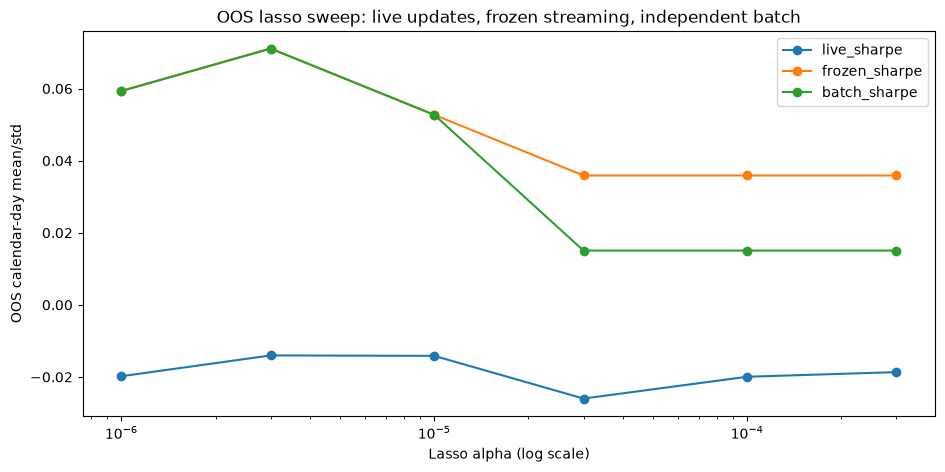

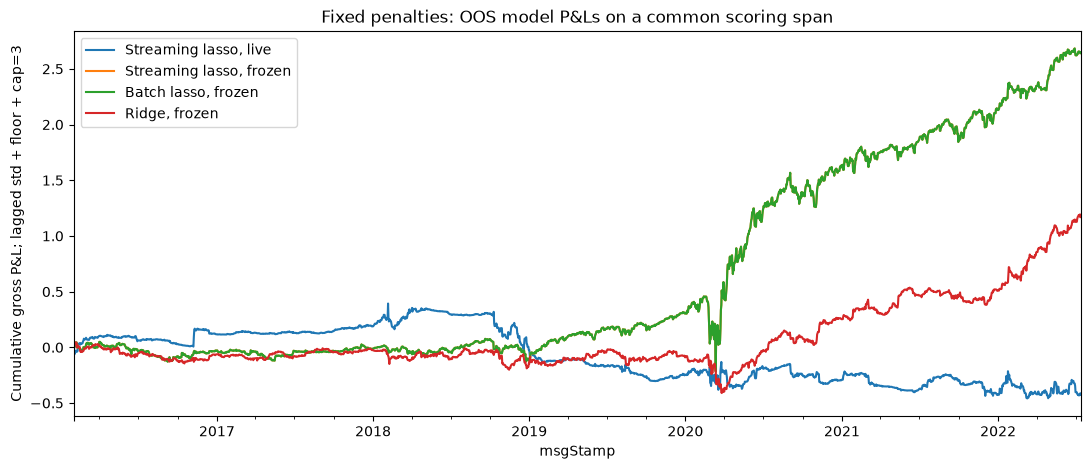

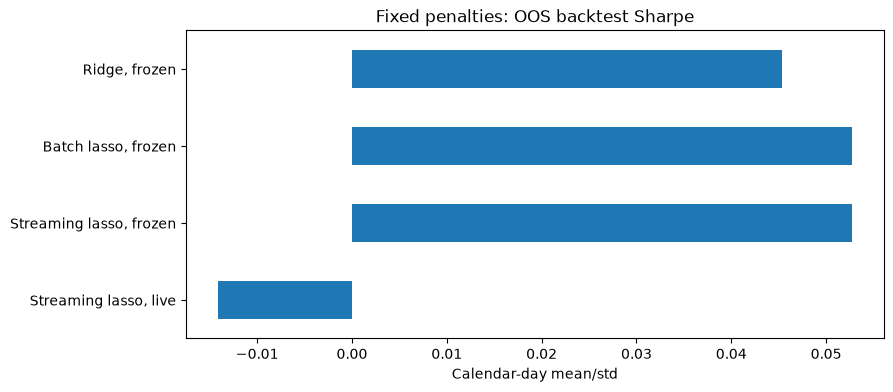

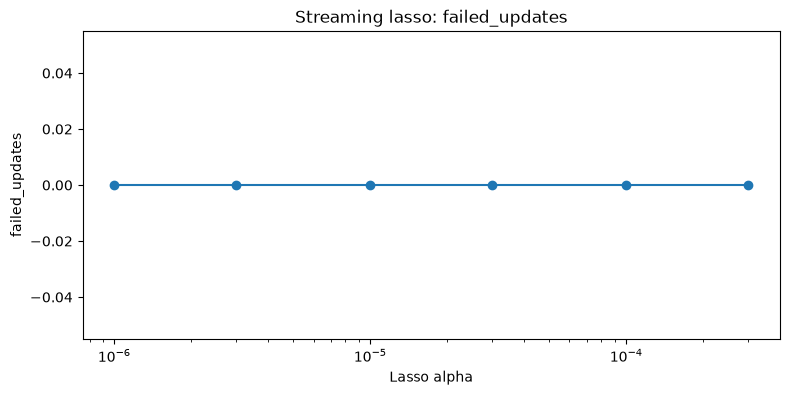

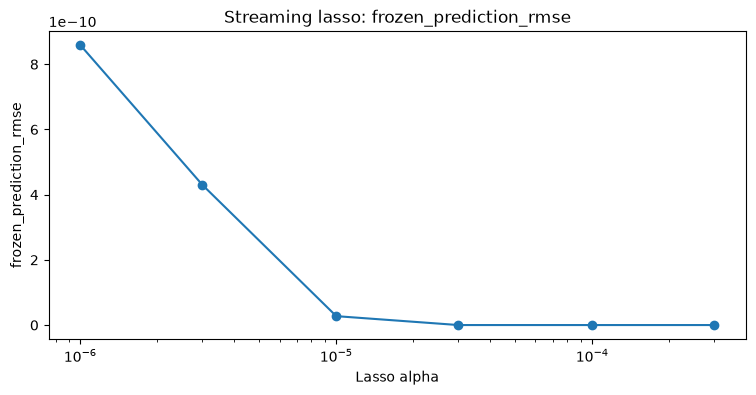

,failed_updates,live_failed_oos_updates,live_warmup_converged,frozen_failed_updates,frozen_terminal_converged
alpha,,,,,
0.000001,0,0,True,80,True
0.000003,0,0,True,6,True
0.000010,0,0,True,3,True
0.000030,0,0,True,0,True
0.000100,0,0,True,1,True
0.000300,0,0,True,0,True


STREAMING_CONVERGENCE_AUDIT
          live_sharpe  frozen_sharpe  batch_sharpe  frozen_prediction_rmse  frozen_max_abs_error  failed_updates  live_failed_oos_updates  live_warmup_converged  frozen_terminal_converged  frozen_failed_updates     final_KKT     seconds     slope  correlation
alpha                                                                                                                                                                                                                                                              
0.000001    -0.019798       0.059321      0.059321            8.588820e-10          3.084551e-08               0                        0                   True                       True                     80  9.910399e-11  652.428486 -0.134654    -0.010608
0.000003    -0.014029       0.071100      0.071101            4.297449e-10          1.009166e-08               0                        0                   True                       True     

In [32]:
online_results, online_rows, stream_daily = {}, [], {}
audit_ids = np.unique(np.linspace(0, len(folds)-1, 6, dtype=int)).tolist()
for alpha in LASSO_ALPHAS:
    m = StreamingWeightedLasso(len(fit_columns), DECAY, float(alpha), max_iter=20000, tol=1e-10,
                              fit_intercept=True, store_history=True if alpha==DEFAULT_ALPHA else False)
    started = perf_counter()
    result = stream_at_folds(m, X_fit, y_fit, folds, W=W_fit,
                            audit_folds=audit_ids if alpha==DEFAULT_ALPHA else ())
    seconds = perf_counter()-started
    live_daily, live_stats = score_prediction(oos_series(result['live']))
    frozen_daily, frozen_stats = score_prediction(oos_series(result['frozen']))
    live_valid = result['live_warmup_converged'] and result['live_failed_oos_updates'] == 0
    frozen_valid = bool(np.all(result['frozen_converged']))
    reference = batch_paths[f'Lasso {alpha:g}'].prediction_
    difference = result['frozen']-reference
    online_rows.append(dict(alpha=alpha, live_sharpe=live_stats['daily_sharpe'] if live_valid else np.nan,
        frozen_sharpe=frozen_stats['daily_sharpe'] if frozen_valid else np.nan,
        batch_sharpe=batch_sweep.loc[('Lasso',alpha),'daily_sharpe'],
        frozen_prediction_rmse=np.sqrt(np.nanmean(difference**2)),
        frozen_max_abs_error=np.nanmax(abs(difference)),
        failed_updates=m.n_failed_, live_failed_oos_updates=result['live_failed_oos_updates'],
        live_warmup_converged=bool(result['live_warmup_converged']), frozen_terminal_converged=frozen_valid,
        frozen_failed_updates=int(np.sum(result.get('frozen_failed_updates', []))),
        final_KKT=m.kkt_violation_, seconds=seconds,
        slope=live_stats['slope'], correlation=live_stats['correlation']))
    online_results[float(alpha)] = result
    stream_daily[float(alpha)] = live_daily
    if alpha==DEFAULT_ALPHA:
        fitter, online_yhat, default_result = m, pd.Series(result['live'], index=df.index), result
        default_live_daily, default_frozen_daily = live_daily, frozen_daily
    print(f'ONLINE alpha={alpha:g}: {seconds:.2f}s; failed updates={m.n_failed_}', flush=True)
online_sweep = pd.DataFrame(online_rows).set_index('alpha')
online_sweep[['live_sharpe','frozen_sharpe','batch_sharpe']].plot(
    logx=True,marker='o',figsize=(11,5),title='OOS lasso sweep: live updates, frozen streaming, independent batch')
plt.xlabel('Lasso alpha (log scale)'); plt.ylabel('OOS calendar-day mean/std')
plt.show(); plt.close('all')
comparison_daily = pd.DataFrame({
    'Streaming lasso, live': default_live_daily,
    'Streaming lasso, frozen': default_frozen_daily,
    'Batch lasso, frozen': batch_daily[f'Lasso {DEFAULT_ALPHA:g}'],
    'Ridge, frozen': batch_daily[f'Ridge {RIDGE_ALPHA:g}'],
})
comparison_daily.cumsum().plot(figsize=(13,5),title='Fixed penalties: OOS model P&Ls on a common scoring span')
plt.ylabel('Cumulative gross P&L; lagged std + floor + cap=3'); plt.show(); plt.close('all')


comparison_daily.pipe(sharpe).plot.barh(figsize=(9,4),title='Fixed penalties: OOS backtest Sharpe')
plt.xlabel('Calendar-day mean/std'); plt.show(); plt.close('all')
for metric in ['failed_updates', 'frozen_prediction_rmse']:
    online_sweep[metric].plot(logx=True,marker='o',figsize=(9,4),title=f'Streaming lasso: {metric}')
    plt.xlabel('Lasso alpha'); plt.ylabel(metric); plt.show(); plt.close('all')

# Intermediate replay updates do not determine a frozen fit's terminal accuracy.
# Keep their counts visible. Never treat an unconverged live/terminal path as a
# valid sweep score; the fixed comparison must itself be validated.
display(online_sweep[['failed_updates','live_failed_oos_updates','live_warmup_converged',
                      'frozen_failed_updates','frozen_terminal_converged']])
assert default_result['live_warmup_converged'] and default_result['live_failed_oos_updates'] == 0
assert np.all(default_result['frozen_converged'])
print('STREAMING_CONVERGENCE_AUDIT'); print(online_sweep.to_string())


### Investigating a performance gap

Compare the frozen prediction vectors, not just Sharpe. At selected identical two-year training windows, compare weighted means, standardized covariance/cross-moments and original-unit loss. Then repeat the row-residual CVXPY reference on real 4,096-row windows. This tests the actual feature scales, imputation and returns rather than relying only on synthetic arrays.

The dszl-transformed, zero-imputed design, W=1, decay, intercept, penalty, warm-up and test timestamps are identical in the frozen comparison. Coefficients may be non-unique for redundant predictors, so prediction and objective agreement are more informative than raw coefficient differences. A live-versus-frozen gap can instead reflect refitting frequency or estimation noise. The raw forecast error is checked independently of the capped sizing. No shared inverse-variance denominator is used to manufacture agreement.

In [33]:
audit_rows = []
reference_path = batch_paths[f'Lasso {DEFAULT_ALPHA:g}']
for i in audit_ids:
    start, stop = folds[i]['train_start'], folds[i]['train_stop']
    moments = batch_moments(X_fit[start:stop], y_fit[start:stop], W_fit[start:stop], DECAY)
    G, h, scale, v = _scaled_moments(moments, True)
    state = default_result['states'][i]
    theta = default_result['coefs'][i]*scale
    objective = .5*(v-2*h@theta+theta@G@theta)+DEFAULT_ALPHA*abs(theta).sum()
    audit_rows.append(dict(fold=i, training_start=start, training_stop=stop,
        max_scaled_mean_error=np.max(abs(state[0]-moments[0])/scale),
        max_standardized_cov_error=np.max(abs(state[2]-moments[2])/scale[:,None]/scale),
        max_scaled_cross_error=np.max(abs(state[3]-moments[3])/scale),
        objective_gap=abs(objective-reference_path.objectives_[i]),
        streaming_KKT=default_result['kkt_at_folds'][i]))
implementation_audit = pd.DataFrame(audit_rows)
display(implementation_audit)
print('TWO_YEAR_WINDOW_AUDIT'); print(implementation_audit.to_string(index=False))

real_checks=[]
for stop in [folds[0]['train_stop'], folds[len(folds)//2]['train_stop'], len(df)]:
    start=max(0,stop-4096)
    xx, yy, ww=X_fit[start:stop], y_fit[start:stop], W_fit[start:stop]
    direct=CvxpyWeightedLasso(len(fit_columns),DECAY,DEFAULT_ALPHA,fit_intercept=True,tol=1e-12).fit(xx,yy,W=ww)
    compiled=StreamingWeightedLasso(len(fit_columns),DECAY,DEFAULT_ALPHA,fit_intercept=True,
                                  tol=1e-11,max_iter=50000).fit(xx,yy,W=ww)
    fast_batch=BatchLasso(len(fit_columns),DECAY,DEFAULT_ALPHA,fit_intercept=True,tol=1e-12).fit(xx,yy,W=ww)
    real_checks.append(dict(training_stop=stop, rows=stop-start,
        stream_vs_row_cvxpy_max_error=np.max(abs(compiled.predict(xx)-direct.predict(xx))),
        batch_vs_row_cvxpy_max_error=np.max(abs(fast_batch.predict(xx)-direct.predict(xx))),
        final_stream_KKT=compiled.kkt_violation_, final_converged=compiled.converged_))
real_checks=pd.DataFrame(real_checks); display(real_checks)
print('REAL_ROW_CVXPY_CHECKS'); print(real_checks.to_string(index=False))

# Strictly solve the SAME moments without appending another observation.
from takehome.fitters import _coordinate_descent
worst=int(implementation_audit.loc[implementation_audit.objective_gap.idxmax(),'fold'])
start,stop=folds[worst]['train_start'],folds[worst]['train_stop']
a,b=folds[worst]['predict_start'],folds[worst]['predict_stop']
strict_moments=batch_moments(X_fit[start:stop],y_fit[start:stop],W_fit[start:stop],DECAY)
G,h,scale,v=_scaled_moments(strict_moments,True)
theta=default_result['coefs'][worst]*scale
iterations,kkt,tolerance=_coordinate_descent(G,h,theta,DEFAULT_ALPHA,500000,1e-13)
mx,my=strict_moments[:2]
strict_prediction=X_fit[a:b]@(theta/scale)+(my-mx@(theta/scale))
strict_check=pd.Series(dict(fold=worst, strict_iterations=iterations, strict_KKT=kkt,
    max_next_fold_error=np.max(abs(strict_prediction-reference_path.prediction_[a:b]))))
display(strict_check.to_frame('same_objective_strict_solve'))
print('STRICT_CHECK'); print(strict_check.to_string())

ref=oos_series(reference_path.prediction_)
frozen=oos_series(default_result['frozen'])
matched_predictions = pd.DataFrame({'Batch':ref, 'Frozen stream':frozen})
matched_pnl = backtest(matched_predictions, df.ret_5m, HL, normalization=SIGNAL_RULE)
matched_daily = matched_pnl.where(pd.Series(rows>=SCORE_FIRST,index=df.index),axis=0).resample('D').sum().loc[score_day:]
print('MATCHED_SIZING_SHARPES'); print(matched_daily.pipe(sharpe).to_string())
relative_prediction_error=online_sweep.loc[DEFAULT_ALPHA,'frozen_prediction_rmse']/df.ret_5m.std()
print('Frozen prediction RMSE / target standard deviation:',relative_prediction_error)
print('Numerical agreement and refit-frequency effects must be assessed separately; inspect the diagnostics above.')


,fold,training_start,training_stop,max_scaled_mean_error,max_standardized_cov_error,max_scaled_cross_error,objective_gap,streaming_KKT
0,0,0,150191,7.183677e-16,1.368712e-14,1.023734e-19,1.110937e-19,1.369293e-12
1,1,150191,300384,8.535584e-16,1.638055e-14,5.190382e-20,1.758255e-20,0.000000e+00
2,2,300384,450720,1.109909e-14,1.175537e-14,4.405972e-20,1.380796e-19,0.000000e+00
3,3,450720,600911,6.293695e-15,1.407122e-14,1.224529e-19,1.290666e-19,4.961868e-11


TWO_YEAR_WINDOW_AUDIT
 fold  training_start  training_stop  max_scaled_mean_error  max_standardized_cov_error  max_scaled_cross_error  objective_gap  streaming_KKT
    0               0         150191           7.183677e-16                1.368712e-14            1.023734e-19   1.110937e-19   1.369293e-12
    1          150191         300384           8.535584e-16                1.638055e-14            5.190382e-20   1.758255e-20   0.000000e+00
    2          300384         450720           1.109909e-14                1.175537e-14            4.405972e-20   1.380796e-19   0.000000e+00
    3          450720         600911           6.293695e-15                1.407122e-14            1.224529e-19   1.290666e-19   4.961868e-11


/tmp/ipykernel_2655/3557928562.py:26: RuntimeWarning: 17 updates did not converge; inspect KKT errors or raise max_iter.
  tol=1e-11,max_iter=50000).fit(xx,yy,W=ww)


/tmp/ipykernel_2655/3557928562.py:26: RuntimeWarning: 1 updates did not converge; inspect KKT errors or raise max_iter.
  tol=1e-11,max_iter=50000).fit(xx,yy,W=ww)


,training_stop,rows,stream_vs_row_cvxpy_max_error,batch_vs_row_cvxpy_max_error,final_stream_KKT,final_converged
0,150191,4096,9.845697e-11,1.543630e-12,7.797047e-12,True
1,450720,4096,2.819573e-11,6.863148e-13,2.356494e-12,True
2,640734,4096,2.696393e-10,1.996930e-10,8.917325e-12,True


REAL_ROW_CVXPY_CHECKS
 training_stop  rows  stream_vs_row_cvxpy_max_error  batch_vs_row_cvxpy_max_error  final_stream_KKT  final_converged
        150191  4096                   9.845697e-11                  1.543630e-12      7.797047e-12             True
        450720  4096                   2.819573e-11                  6.863148e-13      2.356494e-12             True
        640734  4096                   2.696393e-10                  1.996930e-10      8.917325e-12             True


,same_objective_strict_solve
fold,2.000000e+00
strict_iterations,1.000000e+00
strict_KKT,0.000000e+00
max_next_fold_error,7.246652e-14


STRICT_CHECK
fold                   2.000000e+00
strict_iterations      1.000000e+00
strict_KKT             0.000000e+00
max_next_fold_error    7.246652e-14


MATCHED_SIZING_SHARPES
Batch            0.052714
Frozen stream    0.052714
Frozen prediction RMSE / target standard deviation: 4.0367515363920085e-08
Numerical agreement and refit-frequency effects must be assessed separately; inspect the diagnostics above.


## Coefficient paths and lagged OOS calibration

The coefficient chart shows the post-update history of the default unit-weight lasso. The scatter uses the **common OOS scoring span**, not the initial fitting period. Both coefficients and intercept are shifted by one row. Calibration is y on yhat, with an intercept, and is not used to rescale predictions.

The coefficient chart omits the first `HL` input rows (`HL = 6048`). This is display-only: the full coefficient/intercept histories, their one-row lag, forecasts and fits are unchanged.


In [34]:
beta = pd.DataFrame(fitter.get_coefs(), index=df.index, columns=fit_columns)
intercept = pd.Series(fitter.get_intercepts(), index=df.index, name='intercept')
# Use the SAME dszl model design, not the raw x columns, and lag BOTH histories.
yhat_values = np.full(len(df), np.nan)
yhat_values[1:] = np.einsum('ij,ij->i', X_fit[1:], beta.to_numpy()[:-1]) + intercept.to_numpy()[:-1]
yhat = pd.Series(yhat_values, index=df.index, name='yhat')
prior_updates = pd.Series(valid_fit, index=df.index).cumsum().shift(fill_value=0)
yhat = yhat.where(prior_updates.gt(0))


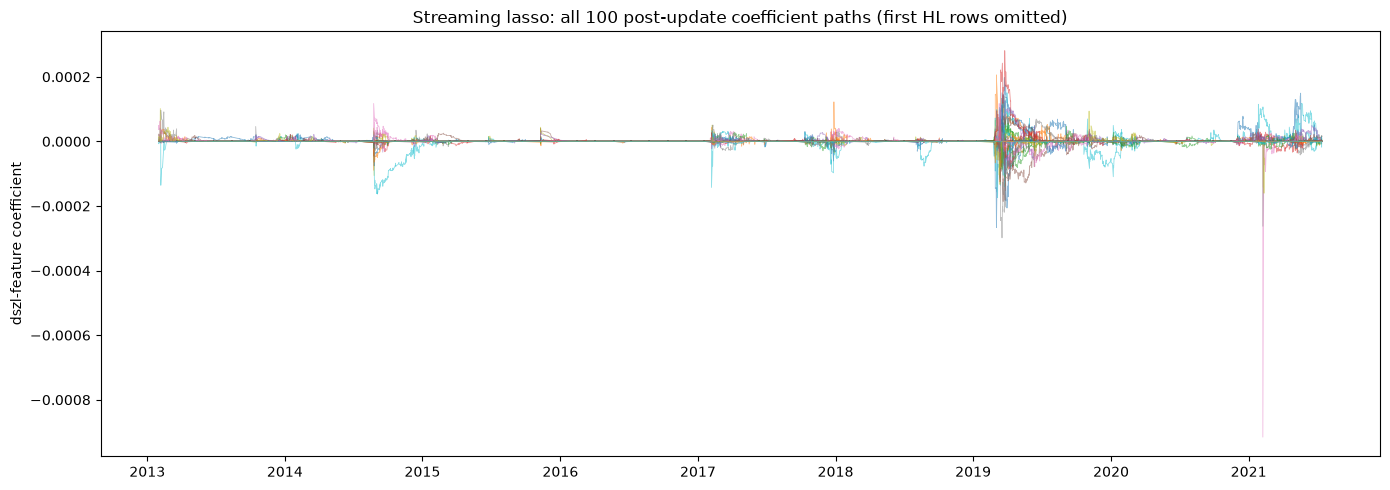

In [35]:
np.testing.assert_allclose(yhat, online_yhat, rtol=1e-9, atol=1e-10, equal_nan=True)
import matplotlib.dates as mdates
with plt.rc_context({'path.simplify': True, 'path.simplify_threshold': 1., 'agg.path.chunksize': 10000}):
    fig, ax = plt.subplots(figsize=(14,5))
    beta_plot = beta.iloc[HL:]  # Display warm-up only; retain the full history.
    clock = beta_plot.index.as_unit('ns').asi8 / 86_400_000_000_000
    ax.plot(clock, beta_plot.to_numpy(), linewidth=.6, alpha=.5, rasterized=True)
    locator=mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator, tz=beta.index.tz))
    ax.set(title='Streaming lasso: all 100 post-update coefficient paths (first HL rows omitted)', ylabel='dszl-feature coefficient')
    fig.tight_layout(); plt.show(); plt.close(fig)


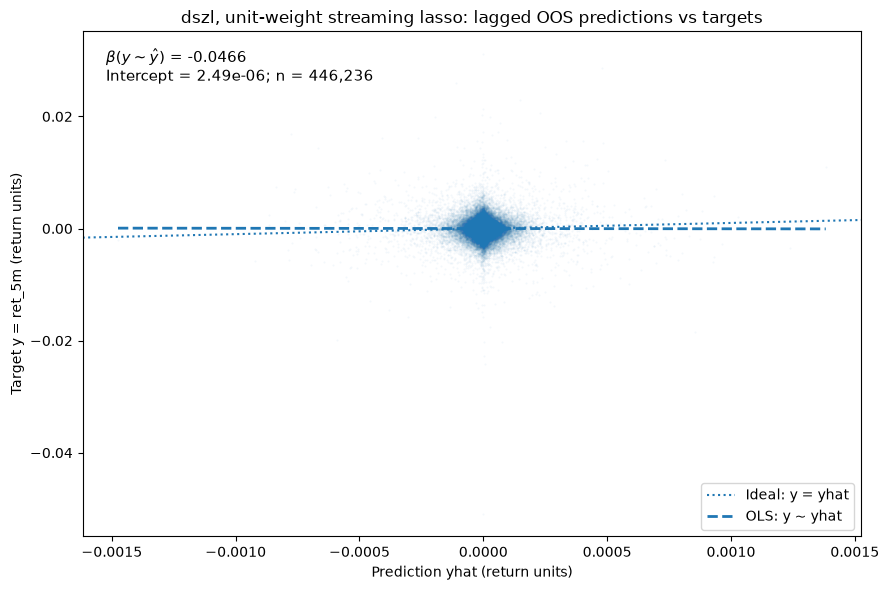

,n,slope,intercept,r_squared
OLS,446236,-0.046592,0.000002,0.000003


OOS_CALIBRATION
          n     slope  intercept  r_squared
OLS  446236 -0.046592   0.000002   0.000003


In [36]:
calibration=plot_calibration(yhat.where(rows>=SCORE_FIRST),df.ret_5m,
    title='dszl, unit-weight streaming lasso: lagged OOS predictions vs targets')
display(calibration)
print('OOS_CALIBRATION'); print(calibration.to_string())


## Final configuration and its non-holdout backtest

The final predictor uses **dszl(10) inputs and Ridge alpha=0.01**, an unpenalized intercept, unit weights on observed labels and the existing 6,048-row forgetting half-life. Both the training interval and the frozen forecast interval are two calendar years. The shared `RIDGE_CONFIG` below is reused unchanged in the final fit; there is no separate Lasso export workflow.

**Why this path:** same-clock-time scaling addresses the seasonal scale structure without requiring future asset prices. Keep all 100 inputs rather than select a few winners from thousands of research candidates. The correlated-feature diagnostics motivate regularization; Ridge retains a distributed combination instead of relying on one unstable active set. Alpha=0.01 is the predeclared reference, not a post-hoc claim of the best validation Sharpe. The grid and frozen/Lasso comparisons above expose sensitivity. The lagged std/floor/cap is a separate, explicit sizing decision chosen for scale invariance and exposure control, not to improve raw prediction calibration.

The next plot is the **exact configuration's prior-window predictions**, scored only in the non-holdout research sample, with the same sizing as the preceding plots. Calibration and errors remain in raw return units. No reserved-label backtest is added at submission time. These are gross diagnostics without transaction costs, and the supplied return timing/feature availability contract still requires confirmation.


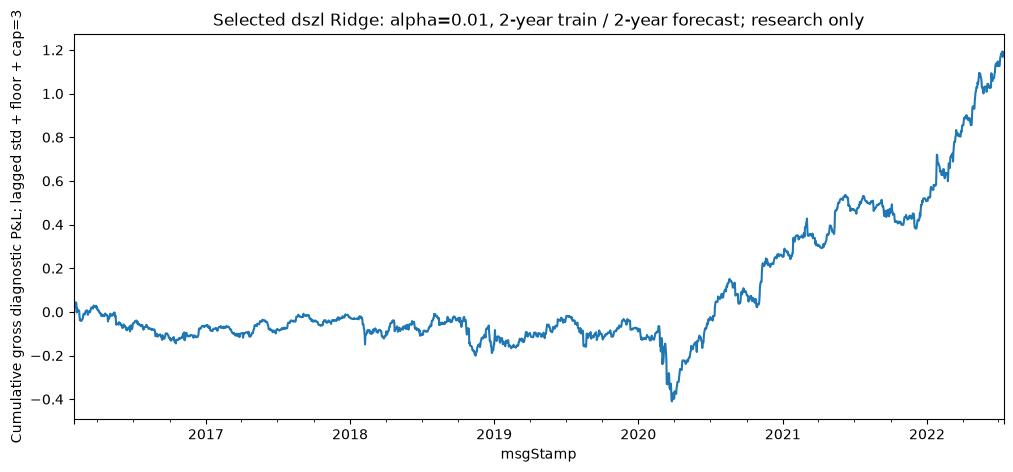

,research_validation
daily_sharpe,0.045334
pnl_observations,446236.000000
max_abs_weight,3.000000
n,446236.000000
slope,0.079575
intercept,0.000002
correlation,0.004700
rmse,0.000714
zero_forecast_rmse,0.000713


,final_configuration
alpha,0.01
decay,0.999885
fit_intercept,True
dszl_hl,10
fit_hl,6048
train_years,2
forecast_years,2
predictor_count,100


SELECTED_RIDGE_VALIDATION
daily_sharpe               0.045334
pnl_observations      446236.000000
max_abs_weight             3.000000
n                     446236.000000
slope                      0.079575
intercept                  0.000002
correlation                0.004700
rmse                       0.000714
zero_forecast_rmse         0.000713


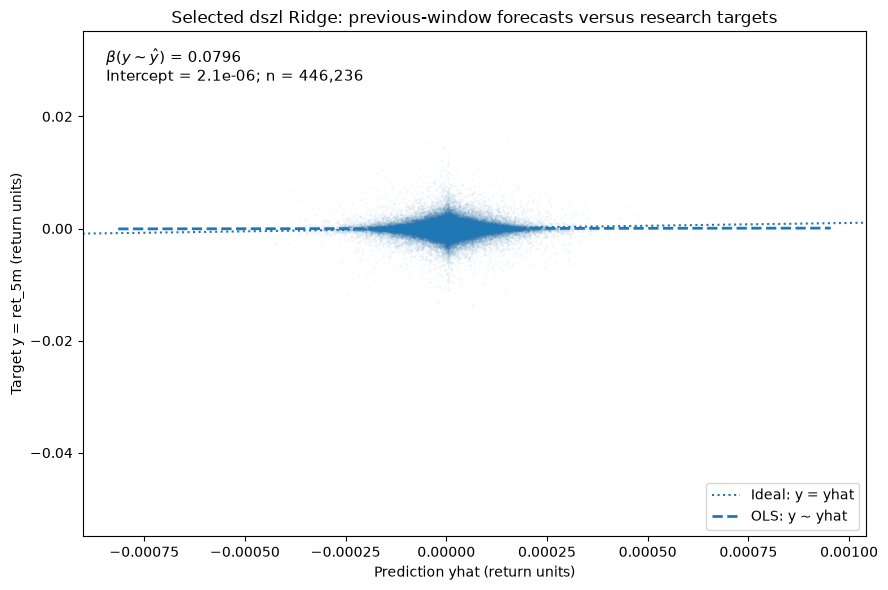

,n,slope,intercept,r_squared
OLS,446236,0.079575,0.000002,0.000022


In [37]:
selected_name = f'Ridge {RIDGE_CONFIG["alpha"]:g}'
selected_prediction = pd.Series(batch_paths[selected_name].prediction_, index=df.index, name='forecast')
selected_daily, selected_stats = score_prediction(selected_prediction)
selected_position = signal_weights(selected_prediction, HL, **SIGNAL_RULE).where(rows>=SCORE_FIRST)
assert selected_position.abs().max() <= SIGNAL_RULE['cap']
selected_daily.cumsum().plot(figsize=(12,5),
    title=f'Selected dszl Ridge: alpha={RIDGE_ALPHA:g}, 2-year train / 2-year forecast; research only')
plt.ylabel('Cumulative gross diagnostic P&L; lagged std + floor + cap=3')
plt.show(); plt.close('all')
selected_metrics = pd.Series(selected_stats, name='research_validation')
display(selected_metrics.to_frame())
display(pd.Series(dict(**RIDGE_CONFIG, dszl_hl=DSZL_HL, fit_hl=HL,
    train_years=WINDOW_YEARS, forecast_years=WINDOW_YEARS, predictor_count=len(fit_columns))).to_frame('final_configuration'))
print('SELECTED_RIDGE_VALIDATION'); print(selected_metrics.to_string())
selected_calibration = plot_calibration(selected_prediction.where(rows>=SCORE_FIRST), df.ret_5m,
    title='Selected dszl Ridge: previous-window forecasts versus research targets')
display(selected_calibration)
research_forecast = selected_prediction.dropna().to_frame()
assert research_forecast.index.max() < split['cutoff']


## Execution environment

Versions used for this evaluation are shown here, rather than exported to a separate file. The figures and statistical results above remain training-only.

In [38]:
from importlib.metadata import version
import platform

print(f'Python {platform.python_version()}')
packages = ['numpy', 'pandas', 'scipy', 'statsmodels', 'matplotlib', 'pyarrow',
            'diptest', 'numba', 'cvxpy', 'clarabel', 'pandas_market_calendars', 'nbformat', 'nbclient', 'ipykernel']
display(pd.Series({p: version(p) for p in packages}, name='version').to_frame())

Python 3.13.15


,version
numpy,2.5.3
pandas,3.0.6
scipy,1.18.1
statsmodels,0.15.0
matplotlib,3.11.2
pyarrow,25.0.1
diptest,0.11.0
numba,0.68.0
cvxpy,1.9.3
clarabel,0.11.1


## Training-only summary and checks

In [39]:
assert df.index.max() < split['cutoff']
assert len(fit_columns) == 100 and fit_columns[-1] == 'x100'
assert fitter.n_seen_ == len(df) == split['train_rows']
print('Research rows:',len(df),'; dszl predictors:',len(fit_columns))
print('Walk-forward scoring starts:',df.index[SCORE_FIRST])
print('Every result above is inside research; reserved labels have not been scored.')


Research rows: 640734 ; dszl predictors: 100
Walk-forward scoring starts: 2016-02-01 18:00:00-05:00
Every result above is inside research; reserved labels have not been scored.


## Submission fit and forecast export — no held-out scoring

Freeze the configuration above. Fit it once on the two calendar years immediately preceding the file's final two-year blackout, then predict every row in that blackout with fixed coefficients. The terminal timestamp is included. The final fit deliberately uses available labels from the formerly research-reserved interval; **none of those labels is evaluated here, used to select a penalty or used to resize a plot**. Every blackout target must be missing.

Build dszl features from the **same original feature-history start**, retaining same-clock-time state across the research split and final training boundary. Read only a small group of feature columns at a time; retain only the final training/prediction rows. This reproduces the same transform without retaining the full multi-year design in memory. Values after a row cannot change its transformed input. x100 is the same un-clipped cashflow/volume ratio; undefined transformed inputs are zero-imputed as in validation. No asset volatility, oracle or extra forecast shift enters this path.

`ridge_oos.csv` / `.parquet` contain `msgStamp,forecast` in raw `ret_5m` units. `ridge_walk_forward.*` contains the research predictions used above. Configuration, fold boundaries, coefficients and checksums are written next to them. The final export cell reuses `RIDGE_CONFIG`; there is no hidden model-specific wrapper.


In [40]:
# Release large diagnostic histories; all validation outputs above are already computed.
import gc
for variable in ('beta', 'beta_plot', 'fitter', 'X_fit', 'model_X', 'raw_features'):
    globals().pop(variable, None)
gc.collect()

final_boundary = file_last - pd.DateOffset(years=WINDOW_YEARS)
final_train_start = final_boundary - pd.DateOffset(years=WINDOW_YEARS)
final_labels = read_parquet_window(DATA_PATH, start=final_train_start, columns=['ret_5m'])
final_index = final_labels.index
final_train_mask = final_index < final_boundary
final_predict_mask = final_index >= final_boundary
assert final_train_mask.any() and final_predict_mask.any()
assert final_labels.loc[final_predict_mask, 'ret_5m'].isna().all(), 'Blackout has observed targets.'
assert final_train_start >= split['first_label']
final_design = np.empty((len(final_index), len(fit_columns)), dtype=np.float64, order='C')
for start in range(0, len(fit_columns), BATCH_SIZE):
    names = fit_columns[start:start+BATCH_SIZE]
    inputs = [c for c in names if c != 'x100']
    if 'x100' in names:
        inputs += ['cashflow', 'volume']
    history = read_parquet_window(DATA_PATH, start=split['first_label'], columns=inputs)
    if 'x100' in names:
        history['x100'] = history.cashflow.div(history.volume.replace(0, np.nan)).replace([np.inf,-np.inf],np.nan)
    block = dszl_design(history[names], hl=DSZL_HL, batch_size=BATCH_SIZE)
    assert final_index.isin(block.index).all()
    final_design[:, start:start+len(names)] = block.loc[final_index].to_numpy()
    del history, block
assert np.isfinite(final_design).all()
print('Final training:', final_train_start, 'to', final_boundary, '(exclusive)')
print('Blackout prediction:', final_index[final_predict_mask][0], 'through', final_index[-1])


Final training: 2022-08-31 17:55:00-04:00 to 2024-08-31 17:55:00-04:00 (exclusive)
Blackout prediction: 2024-09-01 18:00:00-04:00 through 2026-08-31 17:55:00-04:00


In [41]:
# EXACT same model configuration and transformed-feature convention as selected validation.
submission_model = BatchRidge(len(fit_columns), **RIDGE_CONFIG)
final_y = final_labels.loc[final_train_mask, 'ret_5m'].to_numpy(dtype=float)
final_weights = np.isfinite(final_y).astype(float)
assert final_weights.any()
submission_model.fit(final_design[final_train_mask], final_y, W=final_weights)
submission_forecast = pd.DataFrame(
    {'forecast': submission_model.predict(final_design[final_predict_mask])},
    index=final_index[final_predict_mask])
assert submission_forecast.index.is_unique and submission_forecast.index.is_monotonic_increasing
assert submission_forecast.index.equals(final_labels.loc[final_predict_mask].index)
assert np.isfinite(submission_forecast.forecast).all()
print('Finite raw-return forecasts for every withheld row:', len(submission_forecast))
display(submission_forecast.head(), submission_forecast.tail())


Finite raw-return forecasts for every withheld row: 150048


,forecast
msgStamp,
2024-09-01 18:00:00-04:00,0.000008
2024-09-01 18:05:00-04:00,0.000007
2024-09-01 18:10:00-04:00,0.000007
2024-09-01 18:15:00-04:00,0.000016
2024-09-01 18:20:00-04:00,0.000014


,forecast
msgStamp,
2026-08-31 17:35:00-04:00,0.000008
2026-08-31 17:40:00-04:00,0.000008
2026-08-31 17:45:00-04:00,0.000008
2026-08-31 17:50:00-04:00,0.000008
2026-08-31 17:55:00-04:00,0.000008


In [42]:
import hashlib
forecast_dir = Path(os.environ.get('FORECAST_OUTPUT_DIR', ROOT / 'forecasts'))
forecast_dir.mkdir(parents=True, exist_ok=True)
written = {}
for name, frame in [('ridge_walk_forward', research_forecast), ('ridge_oos', submission_forecast)]:
    csv_path, parquet_path = forecast_dir / f'{name}.csv', forecast_dir / f'{name}.parquet'
    frame.to_csv(csv_path, index_label='msgStamp', float_format='%.17g')
    frame.to_parquet(parquet_path)
    written[csv_path.name] = hashlib.sha256(csv_path.read_bytes()).hexdigest()
    written[parquet_path.name] = hashlib.sha256(parquet_path.read_bytes()).hexdigest()
    print(csv_path.resolve())
window_table = pd.DataFrame([dict(kind='research', fold=i, **f) for i,f in enumerate(folds)])
window_table.to_csv(forecast_dir / 'ridge_research_windows.csv', index=False)
pd.Series(submission_model.coef, index=fit_columns, name='coefficient').to_csv(
    forecast_dir / 'ridge_coefficients.csv', index_label='feature')
metadata = dict(model='BatchRidge', model_config=RIDGE_CONFIG, features=fit_columns,
    feature_transform='dszl', dszl_hl=DSZL_HL, dszl_history_start=split['first_label'].isoformat(),
    nonfinite_model_input='zero after dszl', label_weights='unit on finite labels', fit_hl=HL,
    train_years=WINDOW_YEARS, forecast_years=WINDOW_YEARS, sizing_for_diagnostics=SIGNAL_RULE,
    forecast_units='raw ret_5m units; no sizing or extra shift', research_cutoff=split['cutoff'].isoformat(),
    research_forecast_rows=len(research_forecast), research_metrics=selected_stats,
    final_train_start=final_train_start.isoformat(), final_train_stop=final_boundary.isoformat(),
    final_observed_training_labels=int(final_weights.sum()),
    final_fit_uses_research_reserved_labels=True, heldout_scoring=False, blackout_targets_used=False,
    oos_rows=len(submission_forecast), oos_first=submission_forecast.index[0].isoformat(),
    oos_last=submission_forecast.index[-1].isoformat(), intercept=float(submission_model.intercept_), sha256=written)
(forecast_dir / 'ridge_metadata.json').write_text(json.dumps(metadata, indent=2, default=float, allow_nan=False)+'\n')
print('SUBMISSION_METADATA'); print(json.dumps(metadata, indent=2, default=float, allow_nan=False))


/home/runner/work/th/th/forecasts/ridge_walk_forward.csv


/home/runner/work/th/th/forecasts/ridge_oos.csv
SUBMISSION_METADATA
{
  "model": "BatchRidge",
  "model_config": {
    "alpha": 0.01,
    "decay": 0.9998853988984646,
    "fit_intercept": true
  },
  "features": [
    "x1",
    "x2",
    "x3",
    "x4",
    "x5",
    "x6",
    "x7",
    "x8",
    "x9",
    "x10",
    "x11",
    "x12",
    "x13",
    "x14",
    "x15",
    "x16",
    "x17",
    "x18",
    "x19",
    "x20",
    "x21",
    "x22",
    "x23",
    "x24",
    "x25",
    "x26",
    "x27",
    "x28",
    "x29",
    "x30",
    "x31",
    "x32",
    "x33",
    "x34",
    "x35",
    "x36",
    "x37",
    "x38",
    "x39",
    "x40",
    "x41",
    "x42",
    "x43",
    "x44",
    "x45",
    "x46",
    "x47",
    "x48",
    "x49",
    "x50",
    "x51",
    "x52",
    "x53",
    "x54",
    "x55",
    "x56",
    "x57",
    "x58",
    "x59",
    "x60",
    "x61",
    "x62",
    "x63",
    "x64",
    "x65",
    "x66",
    "x67",
    "x68",
    "x69",
    "x70",
    "x71",
    "x72",
   

## Execution provenance

**2026-10-03 23:50 UTC: fresh-kernel, complete top-to-bottom execution** of 42 code cells and 48 embedded figures in 3547.4 seconds, with no cell errors. No prior output was retained. All research diagnostics and, for the submission notebook, the final Ridge fit/export were run from the displayed code. Model settings, actual fold boundaries and holdout-use limitations are documented in the relevant sections.